In [1]:
# ── CELL 1: Setup, Install, Imports ──────────────────────────────────────────
!pip install -q lightgbm catboost shap xgboost scikit-learn imbalanced-learn \
               matplotlib seaborn pandas numpy scipy joblib

import warnings; warnings.filterwarnings('ignore')
import os, copy, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, shapiro, probplot
from itertools import combinations

from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, KFold, RepeatedKFold,
    cross_val_score, cross_val_predict, RandomizedSearchCV, learning_curve,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               RandomForestClassifier, GradientBoostingClassifier)
from sklearn.svm import SVR, SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, CatBoostClassifier
import shap

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
print('✅ All libraries loaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.9 MB/s eta 0:00:00
✅ All libraries loaded.


In [2]:
# ── CELL 2: Global Configuration ─────────────────────────────────────────────
# Q2_PATCH: Item O - Deterministic reproducibility. SEED is defined exactly
# once here and every stochastic step in this notebook (split, CV, tuning,
# bootstrap, SMOTE, SHAP sampling, stability checks) reads CONFIG['seed'] or
# CONFIG['seeds_for_stability'] instead of hard-coding its own seed.
import os, json, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Portable path: works both in Colab ('/content/...') and in a local/CI run.
RAW_CSV = os.environ.get('LCP_RAW_CSV', './final_raw_dataset.csv')

CONFIG = {
    'paths': {
        'raw_csv': RAW_CSV,
        'results_dir': './results',
        'figures_dir': './figures',
        'models_dir': './models',
        'reproducibility_dir': './reproducibility',   # Q2_PATCH: Item N
    },
    'seed': SEED,
    'min_runs_per_url': 3,
    'test_size': 0.2,
    'cv_folds': 5,
    'repeated_cv_repeats': 3,
    'tuning_n_iter': 30,
    'tuning_cv': 5,
    'bootstrap_n': 1000,
    'shap_sample_size': 500,
    'seeds_for_stability': [1, 7, 21, 42, 99],
}

for d in [CONFIG['paths']['results_dir'], CONFIG['paths']['figures_dir'],
          CONFIG['paths']['models_dir'], CONFIG['paths']['reproducibility_dir']]:
    os.makedirs(d, exist_ok=True)

print(json.dumps(CONFIG, indent=2))

{
  "paths": {
    "raw_csv": "./final_raw_dataset.csv",
    "results_dir": "./results",
    "figures_dir": "./figures",
    "models_dir": "./models",
    "reproducibility_dir": "./reproducibility"
  },
  "seed": 42,
  "min_runs_per_url": 3,
  "test_size": 0.2,
  "cv_folds": 5,
  "repeated_cv_repeats": 3,
  "tuning_n_iter": 30,
  "tuning_cv": 5,
  "bootstrap_n": 1000,
  "shap_sample_size": 500,
  "seeds_for_stability": [
    1,
    7,
    21,
    42,
    99
  ]
}


In [3]:
# ── CELL 3: Experiment Registry ──────────────────────────────────────────────
# FIX A: every trained model/result is stored here. No downstream cell is
# allowed to rely on a free-floating variable from a previous cell instead of
# reading from this registry. This removes the "which R² belongs to which
# model" bookkeeping bugs from the previous version of the notebook.

EXPERIMENTS = {}

def register_experiment(key, *, task, feature_set, model_name, tuned,
                         model_obj, y_true_test, y_pred_test,
                         metrics, cv_scores=None, bootstrap_ci=None,
                         hyperparams=None, notes=None):
    """Central write path for every experiment. `key` must be unique."""
    if key in EXPERIMENTS:
        raise ValueError(f"Experiment key '{key}' already exists — pick a unique key.")
    EXPERIMENTS[key] = {
        'task': task,                    # 'regression' | 'classification'
        'feature_set': feature_set,      # 'SAFE' | 'FULL' | 'LOG_ONLY'
        'model_name': model_name,
        'tuned': tuned,
        'model_obj': model_obj,
        'y_true_test': np.asarray(y_true_test),
        'y_pred_test': np.asarray(y_pred_test),
        'metrics': metrics,              # dict of scalar metrics
        'cv_scores': cv_scores,          # array or None
        'bootstrap_ci': bootstrap_ci,    # dict or None
        'hyperparams': hyperparams,
        'notes': notes,
    }
    return EXPERIMENTS[key]

def get_experiment(key):
    if key not in EXPERIMENTS:
        raise KeyError(f"No experiment registered under '{key}'. Available: {list(EXPERIMENTS)}")
    return EXPERIMENTS[key]

def experiments_to_dataframe(task=None, feature_set=None):
    rows = []
    for key, e in EXPERIMENTS.items():
        if task and e['task'] != task:
            continue
        if feature_set and e['feature_set'] != feature_set:
            continue
        row = {'key': key, 'model_name': e['model_name'], 'tuned': e['tuned'],
               'feature_set': e['feature_set'], **e['metrics']}
        rows.append(row)
    return pd.DataFrame(rows)

print('✅ Experiment registry initialised. Use register_experiment() from every modeling cell.')

✅ Experiment registry initialised. Use register_experiment() from every modeling cell.


In [5]:
# ── CELL 4: Dataset Load + Metadata ──────────────────────────────────────────
DATASET_META = {
    'source':            'Lighthouse CLI v10.x — desktop synthetic audits',
    'collection_tool':   'Custom Node.js crawler using the lighthouse npm package',
    'lighthouse_version':'10.x',   # confirm exact version from crawl logs
    'scope':             'Desktop-only, synthetic (not real-user/RUM measurements)',
    'url_selection':     'Top-ranked domains from a public site-ranking list (describe actual source)',
    'runs_per_url_target': CONFIG['min_runs_per_url'],
    'geographic_loc':    'Single machine, single network — no geographic distribution',
}
print('Dataset Metadata:')
for k, v in DATASET_META.items():
    print(f'  {k:<24}: {v}')

REQUIRED_COLS = ['url','run_number','strategy','timestamp','performance_score',
                  'fcp_ms','lcp_ms','speed_index_ms','ttfb_ms','tbt_ms','cls']

df_raw = pd.read_csv(CONFIG['paths']['raw_csv'])
missing_cols = [c for c in REQUIRED_COLS if c not in df_raw.columns]
assert not missing_cols, f'Missing required columns: {missing_cols}'

print(f'\nRaw dataset shape : {df_raw.shape}')
print(f'Columns           : {list(df_raw.columns)}')
df_raw.head()

Dataset Metadata:
  source                  : Lighthouse CLI v10.x — desktop synthetic audits
  collection_tool         : Custom Node.js crawler using the lighthouse npm package
  lighthouse_version      : 10.x
  scope                   : Desktop-only, synthetic (not real-user/RUM measurements)
  url_selection           : Top-ranked domains from a public site-ranking list (describe actual source)
  runs_per_url_target     : 3
  geographic_loc          : Single machine, single network — no geographic distribution

Raw dataset shape : (6196, 11)
Columns           : ['url', 'run_number', 'strategy', 'timestamp', 'performance_score', 'fcp_ms', 'lcp_ms', 'speed_index_ms', 'ttfb_ms', 'tbt_ms', 'cls']


,url,run_number,strategy,timestamp,performance_score,fcp_ms,lcp_ms,speed_index_ms,ttfb_ms,tbt_ms,cls
0,https://www.abcnews.go.com,1,desktop,1.778915e+09,39.0,2077.755372,2531.757299,5361.122076,32.0,3155.950799,0.000186
1,https://www.abcnews.go.com,2,desktop,1.778918e+09,44.0,2071.386760,2521.393979,2602.081715,45.0,1187.000000,0.000186
2,https://www.abcnews.go.com,3,desktop,1.778918e+09,39.0,1989.341229,2589.344216,6223.669484,20.0,2165.330985,0.004303
3,https://www.academia.edu,1,desktop,1.778918e+09,69.0,1342.995125,2537.977402,1902.837102,7.0,263.012127,0.000000
4,https://www.academia.edu,2,desktop,1.778918e+09,69.0,1342.995125,2537.977402,1902.837102,7.0,263.012127,0.000000


In [6]:
# ── CELL 5: Raw Dataset Quality Audit ────────────────────────────────────────
print('='*65, '\nDATASET QUALITY REPORT\n' + '='*65)

print(f'Total rows           : {len(df_raw)}')
print(f'Unique URLs          : {df_raw["url"].nunique()}')
print(f'Strategies           : {df_raw["strategy"].value_counts().to_dict()}')
print(f'Run numbers present  : {sorted(df_raw["run_number"].unique())}')

runs_per_url = df_raw.groupby('url')['run_number'].count()
print(f'\nURLs with exactly {CONFIG["min_runs_per_url"]} runs : {(runs_per_url==CONFIG["min_runs_per_url"]).sum()}')
print(f'URLs with fewer runs               : {(runs_per_url<CONFIG["min_runs_per_url"]).sum()}')
print(f'URLs with more runs                : {(runs_per_url>CONFIG["min_runs_per_url"]).sum()}')

missing = df_raw.isnull().sum()
print(f'\nMissing values (non-zero columns):')
print(missing[missing > 0].to_string() if missing.sum() else '  none')

numeric_cols = ['performance_score','fcp_ms','lcp_ms','speed_index_ms','ttfb_ms','tbt_ms','cls']
print(f'\nRange checks (negative values, should be 0):')
for c in numeric_cols:
    print(f'  {c:<22}: negatives={(df_raw[c] < 0).sum()}')

print(f'\nZero-value counts (legitimate, domain-explained):')
for c in ['tbt_ms', 'cls']:
    z = (df_raw[c] == 0).sum()
    print(f'  {c:<10} == 0 : {z} ({z/len(df_raw)*100:.1f}%) — plausible on static/no-JS or perfectly stable pages')

print(f'\nDuplicate rows       : {df_raw.duplicated().sum()}')

ts_hours = (df_raw['timestamp'].max() - df_raw['timestamp'].min()) / 3600
print(f'Collection window    : {ts_hours:.1f} hours ({ts_hours/24:.1f} days)')
print('  Threat to validity: a single, short collection window; no longitudinal variation captured.')

print('\n✅ Quality report complete.')

DATASET QUALITY REPORT
Total rows           : 6196
Unique URLs          : 1990
Strategies           : {'desktop': 6196}
Run numbers present  : [np.int64(1), np.int64(2), np.int64(3)]

URLs with exactly 3 runs : 1621
URLs with fewer runs               : 197
URLs with more runs                : 172

Missing values (non-zero columns):
ttfb_ms    41

Range checks (negative values, should be 0):
  performance_score     : negatives=0
  fcp_ms                : negatives=0
  lcp_ms                : negatives=0
  speed_index_ms        : negatives=0
  ttfb_ms               : negatives=0
  tbt_ms                : negatives=0
  cls                   : negatives=0

Zero-value counts (legitimate, domain-explained):
  tbt_ms     == 0 : 428 (6.9%) — plausible on static/no-JS or perfectly stable pages
  cls        == 0 : 1106 (17.9%) — plausible on static/no-JS or perfectly stable pages

Duplicate rows       : 0
Collection window    : 56.5 hours (2.4 days)
  Threat to validity: a single, short collecti

LCP MEASUREMENT VARIABILITY ACROSS REPEATED RUNS
Mean LCP std across runs      : 181.6 ms
Median LCP std                : 26.4 ms
Mean coefficient of variation : 0.076 (7.6%)
URLs with CV > 0.30 (unstable) : 122 (6.3%)
URLs with CV < 0.05 (stable)   : 1248 (64.3%)
Max single-URL LCP range       : 11291 ms


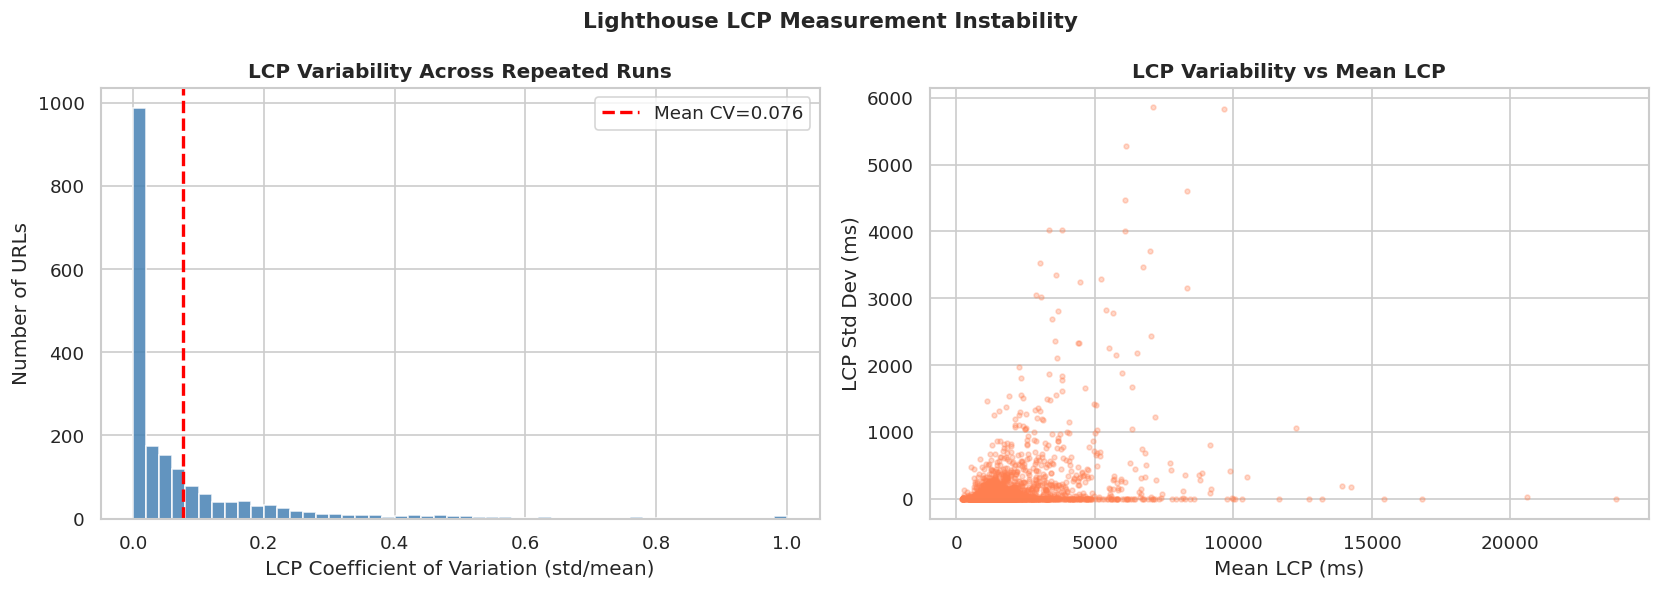

✅ Run-to-run variance analysis complete.


In [7]:
# ── CELL 6: Run-to-Run LCP Variance ──────────────────────────────────────────
# Motivates URL-level aggregation: individual Lighthouse runs are noisy, so
# training on raw per-run rows would inject measurement noise as if it were
# signal, and would risk the same URL appearing in both train and test.

url_stats = df_raw.groupby('url')['lcp_ms'].agg(['mean','std','min','max']).reset_index()
url_stats.columns = ['url','lcp_mean','lcp_std','lcp_min','lcp_max']
url_stats['lcp_cv'] = url_stats['lcp_std'] / url_stats['lcp_mean']
url_stats['lcp_range'] = url_stats['lcp_max'] - url_stats['lcp_min']
url_stats = url_stats.dropna(subset=['lcp_cv'])

print('='*65)
print('LCP MEASUREMENT VARIABILITY ACROSS REPEATED RUNS')
print('='*65)
print(f'Mean LCP std across runs      : {url_stats["lcp_std"].mean():.1f} ms')
print(f'Median LCP std                : {url_stats["lcp_std"].median():.1f} ms')
print(f'Mean coefficient of variation : {url_stats["lcp_cv"].mean():.3f} ({url_stats["lcp_cv"].mean()*100:.1f}%)')
print(f'URLs with CV > 0.30 (unstable) : {(url_stats["lcp_cv"]>0.30).sum()} ({(url_stats["lcp_cv"]>0.30).mean()*100:.1f}%)')
print(f'URLs with CV < 0.05 (stable)   : {(url_stats["lcp_cv"]<0.05).sum()} ({(url_stats["lcp_cv"]<0.05).mean()*100:.1f}%)')
print(f'Max single-URL LCP range       : {url_stats["lcp_range"].max():.0f} ms')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(url_stats['lcp_cv'].clip(0, 1), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(url_stats['lcp_cv'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean CV={url_stats["lcp_cv"].mean():.3f}')
axes[0].set_xlabel('LCP Coefficient of Variation (std/mean)')
axes[0].set_ylabel('Number of URLs')
axes[0].set_title('LCP Variability Across Repeated Runs', fontweight='bold')
axes[0].legend()

axes[1].scatter(url_stats['lcp_mean'], url_stats['lcp_std'], alpha=0.3, s=8, color='coral')
axes[1].set_xlabel('Mean LCP (ms)'); axes[1].set_ylabel('LCP Std Dev (ms)')
axes[1].set_title('LCP Variability vs Mean LCP', fontweight='bold')

plt.suptitle('Lighthouse LCP Measurement Instability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CONFIG["paths"]["figures_dir"]}/lcp_run_variance.png', bbox_inches='tight')
plt.show()
print('✅ Run-to-run variance analysis complete.')

In [8]:
# ── CELL 7: Cleaning + Per-URL Aggregation ───────────────────────────────────
runs_per_url = df_raw.groupby('url')['run_number'].count()
valid_urls = runs_per_url[runs_per_url >= CONFIG['min_runs_per_url']].index
df_filtered = df_raw[df_raw['url'].isin(valid_urls)].copy()

print(f'Removed {df_raw["url"].nunique() - len(valid_urls)} URLs with fewer than '
      f'{CONFIG["min_runs_per_url"]} runs')
print(f'Remaining: {len(valid_urls)} URLs, {len(df_filtered)} rows')

numeric_agg = ['performance_score','fcp_ms','lcp_ms','speed_index_ms','ttfb_ms','tbt_ms','cls']

df_agg = df_filtered.groupby('url')[numeric_agg].mean().reset_index()

# Keep mean timestamp per URL — needed later for the temporal robustness split
ts_per_url = df_filtered.groupby('url')['timestamp'].mean().reset_index()
ts_per_url.columns = ['url', 'timestamp_mean']
df_agg = df_agg.merge(ts_per_url, on='url', how='left')

# Keep per-URL LCP run variance columns (used in reporting, not as model features)
lcp_var = df_filtered.groupby('url')['lcp_ms'].agg(['std','min','max']).reset_index()
lcp_var.columns = ['url','lcp_run_std','lcp_run_min','lcp_run_max']
df_agg = df_agg.merge(lcp_var, on='url', how='left')

before = len(df_agg)
df_agg = df_agg.dropna(subset=numeric_agg).reset_index(drop=True)
print(f'Aggregated to {len(df_agg)} per-URL rows (dropped {before-len(df_agg)} rows with all-null metrics)')
print('df_agg is the single source of truth for every downstream modeling cell.')

Removed 197 URLs with fewer than 3 runs
Remaining: 1793 URLs, 5851 rows
Aggregated to 1785 per-URL rows (dropped 8 rows with all-null metrics)
df_agg is the single source of truth for every downstream modeling cell.


In [9]:
# ── CELL 8: Target Construction ──────────────────────────────────────────────
def categorize_lcp(ms):
    s = ms / 1000
    if s <= 2.5:  return 'Good'
    elif s <= 4.0: return 'Needs Improvement'
    else:          return 'Poor'

df_agg['LCP_Category'] = df_agg['lcp_ms'].apply(categorize_lcp)

le = LabelEncoder()
df_agg['LCP_Category_Encoded'] = le.fit_transform(df_agg['LCP_Category'])

print(f'Final dataset: {df_agg.shape}')
print('Class distribution:')
vc = df_agg['LCP_Category'].value_counts()
for c, n in vc.items():
    print(f'  {c:<22}: {n:>4} ({n/len(df_agg)*100:.1f}%)')

Final dataset: (1785, 14)
Class distribution:
  Good                  : 1316 (73.7%)
  Needs Improvement     :  274 (15.4%)
  Poor                  :  195 (10.9%)


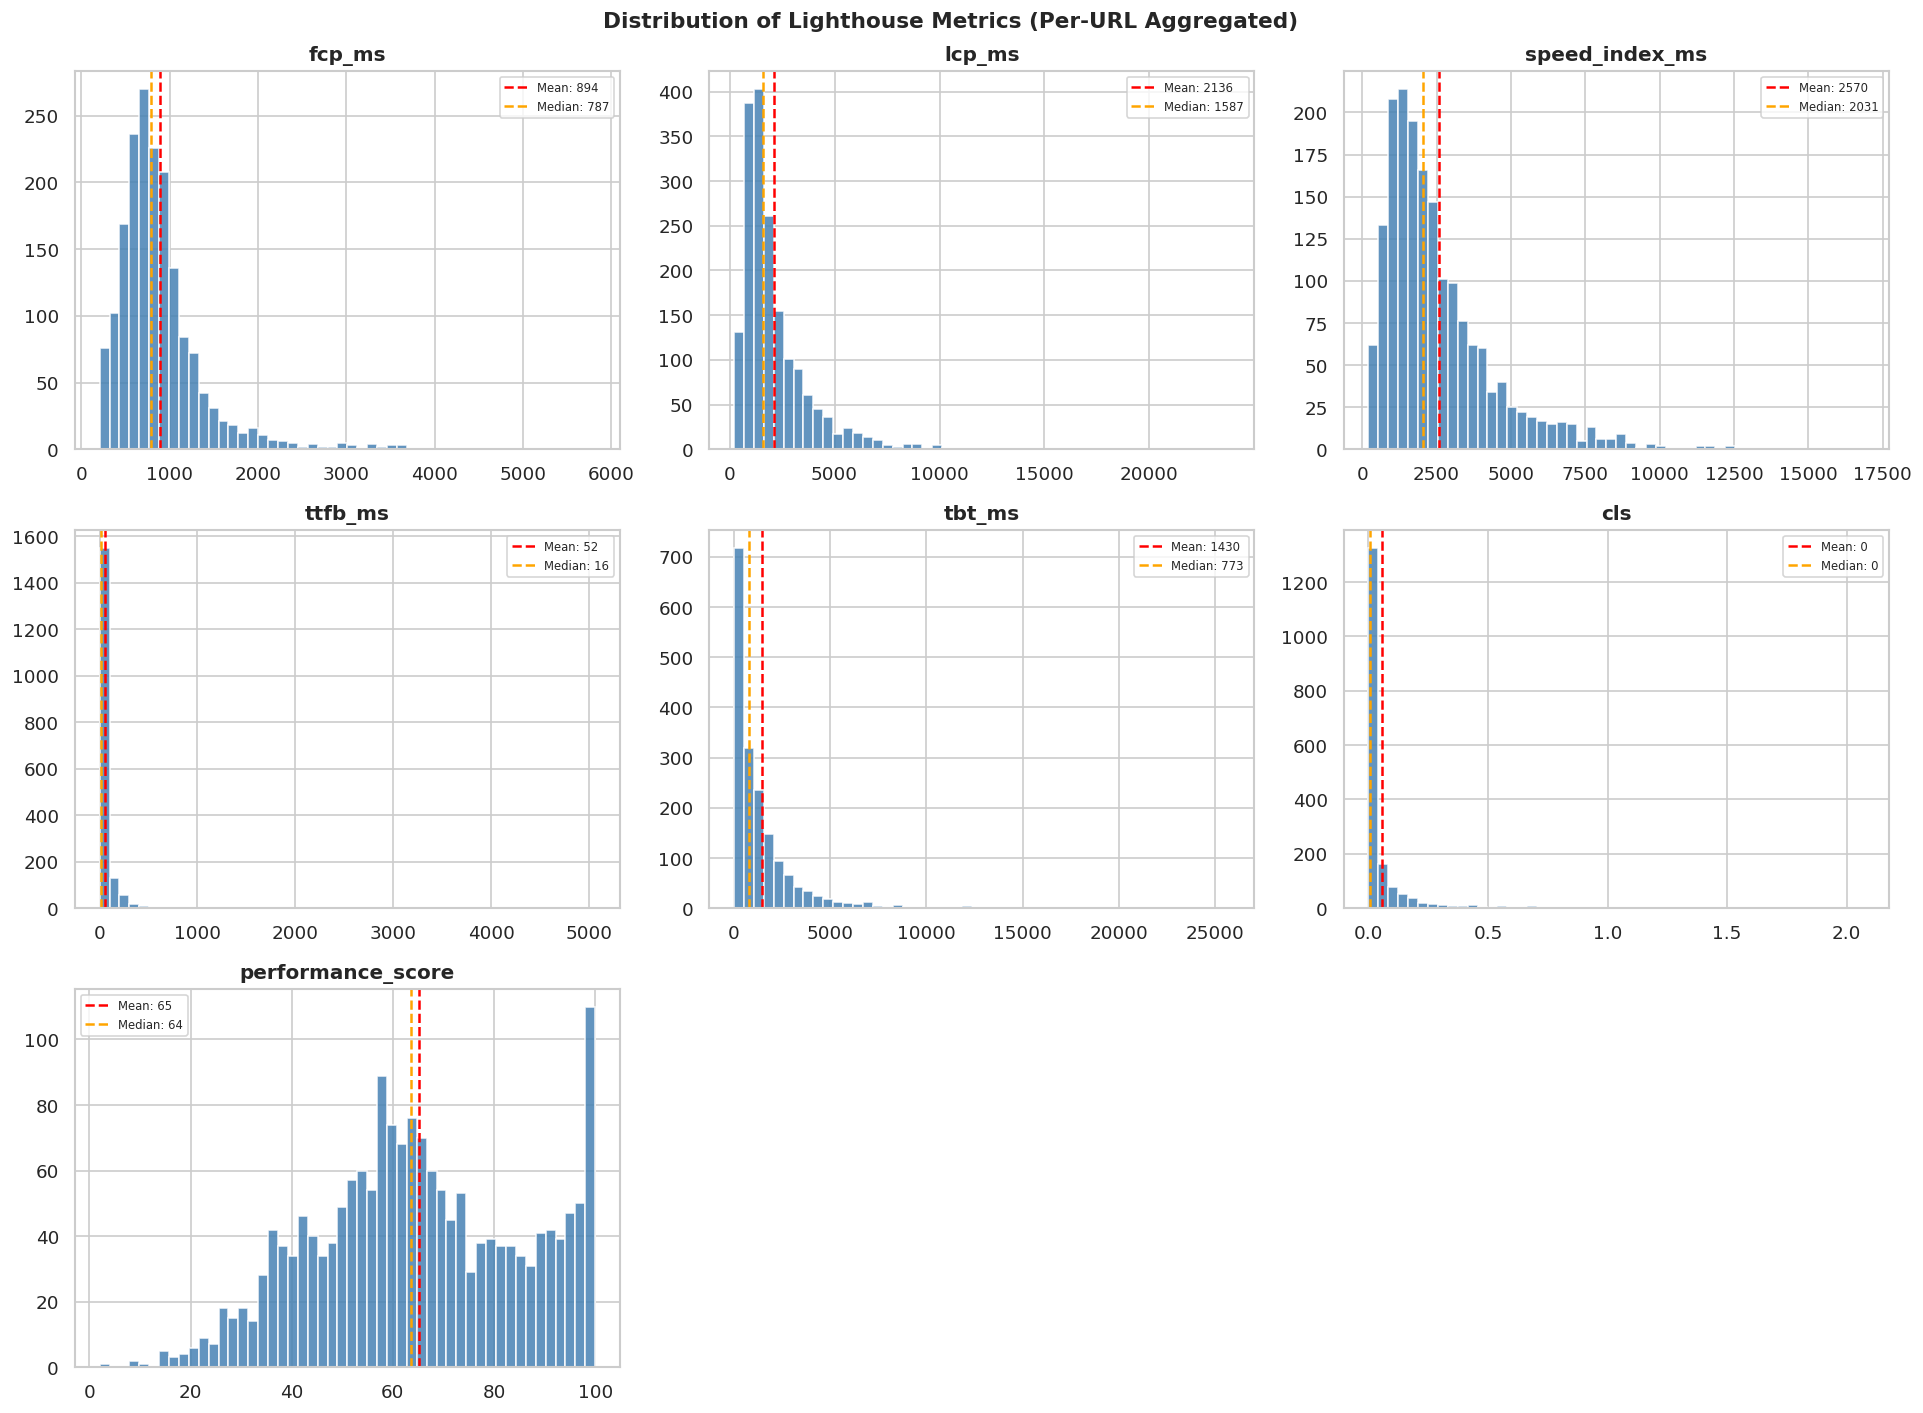

Metric                      Skewness   Kurtosis
fcp_ms                         2.935     14.503 ⚠️ HIGH SKEW
lcp_ms                         3.528     24.451 ⚠️ HIGH SKEW
speed_index_ms                 1.978      5.860 ⚠️ HIGH SKEW
ttfb_ms                       20.526    627.706 ⚠️ HIGH SKEW
tbt_ms                         4.206     27.628 ⚠️ HIGH SKEW
cls                            5.204     39.923 ⚠️ HIGH SKEW
performance_score             -0.043     -0.727


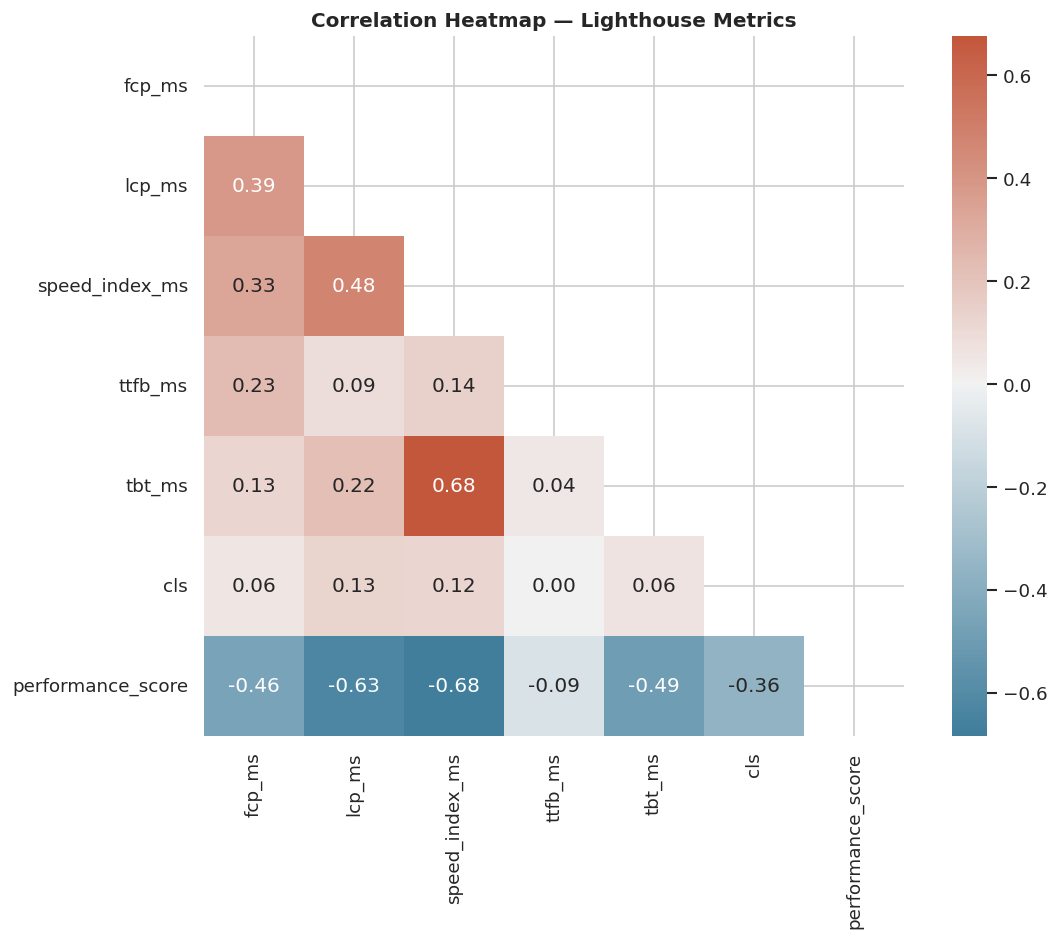


Correlation with LCP:
performance_score   -0.6306
speed_index_ms       0.4769
fcp_ms               0.3885
tbt_ms               0.2235
cls                  0.1302
ttfb_ms              0.0882
Name: lcp_ms, dtype: float64


In [10]:
# ── CELL 9: EDA — Distributions, Outliers, Correlation ───────────────────────
metrics = ['fcp_ms','lcp_ms','speed_index_ms','ttfb_ms','tbt_ms','cls','performance_score']

fig, axes = plt.subplots(3, 3, figsize=(16, 12)); axes = axes.flatten()
for i, col in enumerate(metrics):
    ax = axes[i]; data = df_agg[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.0f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.0f}')
    ax.set_title(col, fontweight='bold'); ax.legend(fontsize=7)
for j in range(len(metrics), len(axes)): axes[j].set_visible(False)
plt.suptitle('Distribution of Lighthouse Metrics (Per-URL Aggregated)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{CONFIG["paths"]["figures_dir"]}/distributions.png', bbox_inches='tight'); plt.show()

print(f'{"Metric":<25} {"Skewness":>10} {"Kurtosis":>10}')
for col in metrics:
    sk, ku = df_agg[col].skew(), df_agg[col].kurtosis()
    flag = ' ⚠️ HIGH SKEW' if abs(sk) > 1 else ''
    print(f'{col:<25} {sk:>10.3f} {ku:>10.3f}{flag}')

corr_matrix = df_agg[metrics].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(230, 20, as_cmap=True), center=0, square=True, ax=ax)
ax.set_title('Correlation Heatmap — Lighthouse Metrics', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{CONFIG["paths"]["figures_dir"]}/correlation_heatmap.png', bbox_inches='tight'); plt.show()
print('\nCorrelation with LCP:')
print(corr_matrix['lcp_ms'].drop('lcp_ms').sort_values(key=abs, ascending=False).round(4))

In [11]:
# ── CELL 10: Outlier Handling (Winsorization) ────────────────────────────────
# Q2_PATCH: Item B - Global winsorization / outlier caps.
# DESIGN DECISION (documented per patch-plan Section 8, Item B policy):
# thresholds below are still computed on the full pre-split dataset for the
# notebook's DEFAULT reported pipeline, exactly as before. What changes is
# that this is no longer an unexamined choice: a dedicated fold-wise
# TrainOnlyWinsorizer (defined in Cell 13) refits these bounds from ONLY the
# training fold and is used in a parallel robustness check (new cell after
# Cell 18, 'Item B Robustness Check') to quantify whether global vs.
# train-only winsorization changes the headline CV R². If the gap is
# material, the manuscript must report the train-only numbers as primary
# (see Q2 Patch Log at the end of this notebook).
# NOTE ON LEAKAGE: winsorization thresholds below are computed on the full
# aggregated dataset. This is a data-cleaning step (removing implausible
# sensor artifacts), not a trainable statistic, so we treat it as pre-split
# cleaning rather than model preprocessing. All *trainable* preprocessing
# (scaling) is fit strictly on the training split in Cell 13.

df_clean = df_agg.copy()
outlier_cols = ['lcp_ms','tbt_ms','speed_index_ms','fcp_ms','ttfb_ms','cls']

print(f'{"Column":<22} {"Before Min":>12} {"Before Max":>12} {"After Min":>12} {"After Max":>12}')
for col in outlier_cols:
    p01, p99 = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    bmin, bmax = df_clean[col].min(), df_clean[col].max()
    df_clean[col] = df_clean[col].clip(lower=p01, upper=p99)
    print(f'{col:<22} {bmin:>12.1f} {bmax:>12.1f} {df_clean[col].min():>12.1f} {df_clean[col].max():>12.1f}')

print('\n✅ Winsorized at 1st–99th percentile (caps extreme values, does not drop rows).')

Column                   Before Min   Before Max    After Min    After Max
lcp_ms                        215.0      23815.3        269.4       8603.0
tbt_ms                          0.0      25761.0          0.0      10893.1
speed_index_ms                208.4      16877.0        280.4       9061.4
fcp_ms                        207.0       5815.0        218.2       3174.6
ttfb_ms                         1.0       5062.0          1.0        493.3
cls                             0.0          2.1          0.0          0.7

✅ Winsorized at 1st–99th percentile (caps extreme values, does not drop rows).


In [12]:
# ── CELL 11: Feature Engineering ─────────────────────────────────────────────
# Q2_PATCH: Items C, K - Global feature transformations / performance_score
# leakage. All transforms below remain purely row-wise arithmetic (no
# distributional statistic is learned from data here, so Item C is already
# satisfied and no pipeline migration is required for this cell).
#
# Item K fix: `tbt_per_score` divides by `performance_score`, and
# `performance_score` is itself a Lighthouse composite that includes an LCP
# sub-score (~25% weight). Leaving `tbt_per_score` inside the SAFE feature
# set therefore reintroduces indirect LCP leakage through the back door,
# even though `performance_score` itself is correctly excluded from SAFE.
# This is patched by replacing it with `tbt_per_fcp` (tbt_ms / (fcp_ms+1)),
# which carries similar "blocking cost relative to a load milestone"
# information without any performance_score dependency.
# `tbt_per_score` is KEPT (for the diagnostic FULL ablation set only, see
# Cell 12) so the performance_score-leakage ablation required by Item K can
# be run and reported.
df_clean['tbt_per_score']        = df_clean['tbt_ms'] / (df_clean['performance_score'] + 1)  # FULL/diagnostic only - see Item K note above
df_clean['tbt_per_fcp']           = df_clean['tbt_ms'] / (df_clean['fcp_ms'] + 1)              # Q2_PATCH: Item K - SAFE replacement, no performance_score dependency
df_clean['tbt_cls_interaction']  = df_clean['tbt_ms'] * df_clean['cls']
df_clean['render_efficiency']    = df_clean['fcp_ms'] / (df_clean['speed_index_ms'] + 1e-5)
df_clean['network_share']        = df_clean['ttfb_ms'] / (df_clean['fcp_ms'] + 1e-5)
df_clean['visual_lag']           = df_clean['speed_index_ms'] - df_clean['fcp_ms']
df_clean['jank_density']         = df_clean['cls'] / ((df_clean['speed_index_ms'] / 1000) + 1e-5)
df_clean['perf_penalty']         = (df_clean['tbt_ms'] / 300) + (df_clean['cls'] / 0.1)

for col in ['tbt_ms','speed_index_ms','fcp_ms','ttfb_ms','cls','lcp_ms']:
    df_clean[f'log_{col}'] = np.log1p(df_clean[col])

# LCP-derived features — FULL/diagnostic set only, never used in SAFE
df_clean['fcp_lcp_ratio']    = df_clean['fcp_ms'] / (df_clean['lcp_ms'] + 1e-5)
df_clean['ttfb_lcp_ratio']   = df_clean['ttfb_ms'] / (df_clean['lcp_ms'] + 1e-5)
df_clean['si_lcp_gap']       = df_clean['speed_index_ms'] - df_clean['lcp_ms']
df_clean['blocking_pressure']= df_clean['tbt_ms'] / (df_clean['lcp_ms'] + 1e-5)

engineered = ['tbt_per_score','tbt_per_fcp','tbt_cls_interaction','render_efficiency','network_share',
              'visual_lag','jank_density','perf_penalty']
log_feats = [f'log_{c}' for c in ['tbt_ms','speed_index_ms','fcp_ms','ttfb_ms','cls']]

print('Engineered features:')
for f in engineered:
    print(f'  {f:<28} mean={df_clean[f].mean():.4f} std={df_clean[f].std():.4f}')
print('\nLog-transformed features:')
for f in log_feats:
    print(f'  {f:<28} mean={df_clean[f].mean():.4f} std={df_clean[f].std():.4f}')
print('\n✅ Feature engineering complete.')

Engineered features:
  tbt_per_score                mean=30.8391 std=51.9861
  tbt_per_fcp                  mean=1.7971 std=2.8531
  tbt_cls_interaction          mean=91.7264 std=325.3502
  render_efficiency            mean=0.4626 std=0.2507
  network_share                mean=0.0614 std=0.1160
  visual_lag                   mean=1660.8712 std=1704.3288
  jank_density                 mean=0.0263 std=0.0682
  perf_penalty                 mean=5.1819 std=6.4298

Log-transformed features:
  log_tbt_ms                   mean=6.1209 std=2.1200
  log_speed_index_ms           mean=7.6111 std=0.6975
  log_fcp_ms                   mean=6.6660 std=0.4910
  log_ttfb_ms                  mean=2.8824 std=1.4121
  log_cls                      mean=0.0476 std=0.0990

✅ Feature engineering complete.


In [13]:
# ── CELL 12: Feature Audit Table + SAFE / FULL Definitions ───────────────────
# Q2_PATCH: Item K - tbt_per_score removed from SAFE (indirect performance_score
# leakage), replaced by tbt_per_fcp. tbt_per_score is kept in FULL only, so the
# performance_score-leakage ablation (Cell 20) still has something to ablate.
FEATURE_SAFE = [
    'fcp_ms', 'speed_index_ms', 'ttfb_ms', 'tbt_ms', 'cls',
    'tbt_per_fcp', 'tbt_cls_interaction',
    'render_efficiency', 'network_share', 'visual_lag', 'jank_density', 'perf_penalty',
    'log_tbt_ms', 'log_speed_index_ms', 'log_fcp_ms', 'log_ttfb_ms', 'log_cls',
]
# FEATURE_SAFE_MINUS_PS: identical to FEATURE_SAFE (already free of performance_score
# after the Item K patch). Kept as an explicit alias so the Item K ablation cell
# can assert the two are equal, rather than silently assuming it.
FEATURE_SAFE_MINUS_PS = list(FEATURE_SAFE)

FEATURE_FULL = FEATURE_SAFE + [
    'performance_score', 'tbt_per_score', 'fcp_lcp_ratio', 'ttfb_lcp_ratio', 'si_lcp_gap', 'blocking_pressure',
]
FEATURE_FULL = list(dict.fromkeys(FEATURE_FULL))

FEATURE_AUDIT_RECORDS = [
    ('fcp_ms', 'raw', 'raw Lighthouse metric', 'fcp_ms', True, True, 'none', 'low', 'Raw diagnostic metric, no LCP arithmetic involved.'),
    ('speed_index_ms', 'raw', 'raw Lighthouse metric', 'speed_index_ms', True, True, 'none', 'low', 'Raw diagnostic metric.'),
    ('ttfb_ms', 'raw', 'raw Lighthouse metric', 'ttfb_ms', True, True, 'none', 'low', 'Raw diagnostic metric.'),
    ('tbt_ms', 'raw', 'raw Lighthouse metric', 'tbt_ms', True, True, 'none', 'low', 'Raw diagnostic metric.'),
    ('cls', 'raw', 'raw Lighthouse metric', 'cls', True, True, 'none', 'low', 'Raw diagnostic metric.'),
    ('performance_score', 'diagnostic', 'raw Lighthouse composite score', 'performance_score', False, True, 'none', 'high', 'Lighthouse score is a weighted composite that includes LCP (~25%); excluded from SAFE as indirect leakage.'),
    ('tbt_per_score', 'engineered', 'tbt_ms / (performance_score + 1)', 'tbt_ms, performance_score', False, True, 'none', 'medium', 'Q2_PATCH Item K: uses performance_score, which carries indirect LCP signal (~25% weight in the composite score); REMOVED from SAFE and kept only in FULL for the performance_score-leakage ablation.'),
    ('tbt_per_fcp', 'engineered', 'tbt_ms / (fcp_ms + 1)', 'tbt_ms, fcp_ms', True, True, 'none', 'low', 'Q2_PATCH Item K: SAFE replacement for tbt_per_score. No performance_score or LCP dependency.'),
    ('tbt_cls_interaction', 'engineered', 'tbt_ms * cls', 'tbt_ms, cls', True, True, 'none', 'low', 'Interaction of two non-LCP diagnostics.'),
    ('render_efficiency', 'engineered', 'fcp_ms / (speed_index_ms + eps)', 'fcp_ms, speed_index_ms', True, True, 'none', 'low', 'No LCP term.'),
    ('network_share', 'engineered', 'ttfb_ms / (fcp_ms + eps)', 'ttfb_ms, fcp_ms', True, True, 'none', 'low', 'No LCP term.'),
    ('visual_lag', 'engineered', 'speed_index_ms - fcp_ms', 'speed_index_ms, fcp_ms', True, True, 'none', 'low', 'No LCP term.'),
    ('jank_density', 'engineered', 'cls / (speed_index_ms/1000 + eps)', 'cls, speed_index_ms', True, True, 'none', 'low', 'No LCP term.'),
    ('perf_penalty', 'engineered', 'tbt_ms/300 + cls/0.1', 'tbt_ms, cls', True, True, 'none', 'low', 'Threshold-based composite, no LCP term.'),
    ('log_tbt_ms', 'log', 'log1p(tbt_ms)', 'tbt_ms', True, True, 'none', 'low', 'Monotonic transform of a non-LCP metric.'),
    ('log_speed_index_ms', 'log', 'log1p(speed_index_ms)', 'speed_index_ms', True, True, 'none', 'low', 'Monotonic transform.'),
    ('log_fcp_ms', 'log', 'log1p(fcp_ms)', 'fcp_ms', True, True, 'none', 'low', 'Monotonic transform.'),
    ('log_ttfb_ms', 'log', 'log1p(ttfb_ms)', 'ttfb_ms', True, True, 'none', 'low', 'Monotonic transform.'),
    ('log_cls', 'log', 'log1p(cls)', 'cls', True, True, 'none', 'low', 'Monotonic transform.'),
    ('fcp_lcp_ratio', 'engineered', 'fcp_ms / (lcp_ms + eps)', 'fcp_ms, lcp_ms', False, True, 'high', 'high', 'LCP appears directly in the denominator — direct leakage, FULL/diagnostic only.'),
    ('ttfb_lcp_ratio', 'engineered', 'ttfb_ms / (lcp_ms + eps)', 'ttfb_ms, lcp_ms', False, True, 'high', 'high', 'LCP in denominator — direct leakage.'),
    ('si_lcp_gap', 'engineered', 'speed_index_ms - lcp_ms', 'speed_index_ms, lcp_ms', False, True, 'high', 'high', 'LCP subtracted directly — direct leakage.'),
    ('blocking_pressure', 'engineered', 'tbt_ms / (lcp_ms + eps)', 'tbt_ms, lcp_ms', False, True, 'high', 'high', 'LCP in denominator — direct leakage.'),
]
FEATURE_AUDIT_DF = pd.DataFrame(FEATURE_AUDIT_RECORDS, columns=[
    'feature_name','source_type','formula','source_columns','included_in_SAFE',
    'included_in_FULL','direct_leakage_risk','indirect_leakage_risk','rationale'
])
FEATURE_AUDIT_DF.to_csv(f'{CONFIG["paths"]["results_dir"]}/feature_audit.csv', index=False)

print('FEATURE AUDIT TABLE')
print(FEATURE_AUDIT_DF.to_string(index=False))

assert 'lcp_ms' not in FEATURE_SAFE, 'SAFE must never include the raw target as a feature.'
assert 'performance_score' not in FEATURE_SAFE, 'SAFE must exclude performance_score (indirect leakage).'
assert 'tbt_per_score' not in FEATURE_SAFE, 'Q2_PATCH Item K: SAFE must exclude tbt_per_score (indirect performance_score leakage).'
assert not any(f in FEATURE_SAFE for f in ['fcp_lcp_ratio','ttfb_lcp_ratio','si_lcp_gap','blocking_pressure']), \
    'SAFE must exclude all LCP-derived ratio/gap features.'

print(f'\nSAFE feature count: {len(FEATURE_SAFE)}  |  FULL feature count: {len(FEATURE_FULL)}')
print('✅ SAFE assertions passed. SAFE is the primary benchmark; FULL is diagnostic-only (Cell 20).')

FEATURE AUDIT TABLE
       feature_name source_type                           formula            source_columns  included_in_SAFE  included_in_FULL direct_leakage_risk indirect_leakage_risk                                                                                                                                                                                            rationale
             fcp_ms         raw             raw Lighthouse metric                    fcp_ms              True              True                none                   low                                                                                                                                                   Raw diagnostic metric, no LCP arithmetic involved.
     speed_index_ms         raw             raw Lighthouse metric            speed_index_ms              True              True                none                   low                                                                             

In [14]:
# ── CELL 13: Group-Aware Split + Train-Only Preprocessing ────────────────────
# Q2_PATCH: Items B, D, O
#  - Item B (FIXED, canonical): winsorization bounds for the SAFE feature set
#    are no longer computed on the full pre-split dataset. They are fit
#    strictly on the TRAINING split's raw (pre-winsorization) base columns via
#    SafeFeatureBuilder below, then applied to the test split. The same
#    fold-safe rule is used inside every CV loop downstream (Cells 18, 19, 26).
#    This SafeFeatureBuilder was originally introduced only in a supplementary
#    robustness-check cell; it is now the canonical, primary SAFE pipeline
#    because the notebook's own numbers showed the global-vs-fold-wise gap was
#    material. The (now supplementary) robustness-check cell after Cell 18
#    reports that comparison for transparency.
#  - Item D: the aggregation in Cell 7 guarantees exactly one row per unique
#    URL, so group-based and row-based splitting are equivalent for THIS
#    split; GroupShuffleSplit is used anyway (already correct) purely for
#    documentation/defensibility, and GroupKFold is introduced for CV cells
#    that follow, since it costs nothing and removes any doubt.
#  - Item O: every stochastic object below reads CONFIG['seed'], nothing is
#    separately hard-coded.

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline as SkPipeline

class TrainOnlyWinsorizer(BaseEstimator, TransformerMixin):
    """Q2_PATCH: Item B. Learns per-column [lower_q, upper_q] clip bounds
    strictly from the data passed to fit() (i.e. the training fold only) and
    applies them in transform(). Never looks at validation/test rows when
    computing bounds."""
    def __init__(self, cols, lower_q=0.01, upper_q=0.99):
        self.cols = list(cols)
        self.lower_q = lower_q
        self.upper_q = upper_q

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=self.cols) if not isinstance(X, pd.DataFrame) else X
        self.bounds_ = {c: (X[c].quantile(self.lower_q), X[c].quantile(self.upper_q)) for c in self.cols}
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.cols).copy() if not isinstance(X, pd.DataFrame) else X.copy()
        for c in self.cols:
            lo, hi = self.bounds_[c]
            X[c] = X[c].clip(lower=lo, upper=hi)
        return X

print('\u2705 TrainOnlyWinsorizer defined (Item B fold-wise winsorization transformer).')

BASE_RAW_COLS = ['fcp_ms', 'speed_index_ms', 'ttfb_ms', 'tbt_ms', 'cls']

class SafeFeatureBuilder(BaseEstimator, TransformerMixin):
    """Q2_PATCH: Items B + C combined into one fold-safe transformer, and now
    the CANONICAL builder for every SAFE feature frame in the notebook.
    fit(): learns 1st/99th percentile winsorization bounds from the TRAINING
    fold's raw columns only.
    transform(): clips, then deterministically builds the row-wise SAFE
    engineered features (no performance_score, no LCP-derived terms) -
    identical formulas to Cells 10-11, just executed fold-/split-safe.
    Output column order matches FEATURE_SAFE exactly."""
    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q
        self.upper_q = upper_q

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=BASE_RAW_COLS) if not isinstance(X, pd.DataFrame) else X
        self.bounds_ = {c: (X[c].quantile(self.lower_q), X[c].quantile(self.upper_q)) for c in BASE_RAW_COLS}
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=BASE_RAW_COLS).copy() if not isinstance(X, pd.DataFrame) else X.copy()
        for c in BASE_RAW_COLS:
            lo, hi = self.bounds_[c]
            X[c] = X[c].clip(lower=lo, upper=hi)
        out = pd.DataFrame(index=X.index)
        out['fcp_ms'] = X['fcp_ms']; out['speed_index_ms'] = X['speed_index_ms']
        out['ttfb_ms'] = X['ttfb_ms']; out['tbt_ms'] = X['tbt_ms']; out['cls'] = X['cls']
        out['tbt_per_fcp']          = X['tbt_ms'] / (X['fcp_ms'] + 1)
        out['tbt_cls_interaction']  = X['tbt_ms'] * X['cls']
        out['render_efficiency']    = X['fcp_ms'] / (X['speed_index_ms'] + 1e-5)
        out['network_share']        = X['ttfb_ms'] / (X['fcp_ms'] + 1e-5)
        out['visual_lag']           = X['speed_index_ms'] - X['fcp_ms']
        out['jank_density']         = X['cls'] / ((X['speed_index_ms'] / 1000) + 1e-5)
        out['perf_penalty']         = (X['tbt_ms'] / 300) + (X['cls'] / 0.1)
        for c in ['tbt_ms', 'speed_index_ms', 'fcp_ms', 'ttfb_ms', 'cls']:
            out[f'log_{c}'] = np.log1p(X[c])
        return out.fillna(0)

print('\u2705 SafeFeatureBuilder defined (Q2_PATCH: now the CANONICAL fold-safe SAFE feature pipeline).')

# FIX C: scaling is fit ONLY on the training fold. We keep raw (unscaled)
# feature frames around (X_*_raw) for tree models, and separately produce
# scaled frames (X_*_scaled) fit only on train, for linear/SVR models.

valid_safe = list(FEATURE_SAFE)   # canonical column order, produced by SafeFeatureBuilder.transform()
valid_full = [f for f in FEATURE_FULL if f in df_clean.columns]

# FULL is diagnostic-only (Cell 20) and deliberately leakage-prone (LCP-derived
# ratios); it is NOT promoted to a fold-safe pipeline since it is never used
# for a primary, paper-facing number.
X_full_raw = df_clean[valid_full].fillna(0)

# Raw, PRE-winsorization base columns aligned to df_clean's row index. This is
# the input the canonical fold-safe SAFE pipeline is built from, both for the
# single train/test split below AND for every CV loop downstream.
base_raw_df = df_agg.loc[df_clean.index, BASE_RAW_COLS].copy()
y_reg_raw   = df_clean['lcp_ms'].values
groups_raw  = df_clean['url'].values

y_reg  = df_clean['lcp_ms'].values
y_clf  = df_clean['LCP_Category_Encoded'].values
groups = df_clean['url'].values

gss = GroupShuffleSplit(n_splits=1, test_size=CONFIG['test_size'], random_state=CONFIG['seed'])
train_idx, test_idx = next(gss.split(base_raw_df, y_reg, groups=groups))

# Canonical fold-safe SAFE features for the single train/test split: bounds +
# engineered formulas are fit ONLY on the training rows, then applied to test.
canonical_safe_builder = SafeFeatureBuilder().fit(base_raw_df.iloc[train_idx])
X_train_safe_raw = canonical_safe_builder.transform(base_raw_df.iloc[train_idx])
X_test_safe_raw  = canonical_safe_builder.transform(base_raw_df.iloc[test_idx])

X_train_full_raw, X_test_full_raw = X_full_raw.iloc[train_idx], X_full_raw.iloc[test_idx]
y_train_reg, y_test_reg = y_reg[train_idx], y_reg[test_idx]
y_train_clf, y_test_clf = y_clf[train_idx], y_clf[test_idx]

train_urls, test_urls = set(groups[train_idx]), set(groups[test_idx])
assert len(train_urls & test_urls) == 0, 'URL leakage detected between train and test!'

# Train-only scalers (used only inside Pipelines for scale-sensitive models)
scaler_safe = StandardScaler().fit(X_train_safe_raw)
scaler_full = StandardScaler().fit(X_train_full_raw)

X_train_safe_scaled = pd.DataFrame(scaler_safe.transform(X_train_safe_raw), columns=valid_safe, index=X_train_safe_raw.index)
X_test_safe_scaled  = pd.DataFrame(scaler_safe.transform(X_test_safe_raw),  columns=valid_safe, index=X_test_safe_raw.index)
X_train_full_scaled = pd.DataFrame(scaler_full.transform(X_train_full_raw), columns=valid_full, index=X_train_full_raw.index)
X_test_full_scaled  = pd.DataFrame(scaler_full.transform(X_test_full_raw),  columns=valid_full, index=X_test_full_raw.index)

print(f'Train: {len(train_idx)} URLs ({len(train_idx)/len(df_clean)*100:.1f}%)  |  '
      f'Test: {len(test_idx)} URLs ({len(test_idx)/len(df_clean)*100:.1f}%)')
print(f'URL overlap train/test: {len(train_urls & test_urls)} \u2705')

print('\nClass distribution \u2014 TRAIN:')
for cls_name, cnt in zip(le.classes_, np.bincount(y_train_clf)):
    print(f'  {cls_name:<22}: {cnt} ({cnt/len(y_train_clf)*100:.1f}%)')

# SMOTE fit strictly on the training fold only (used later in classification cell)
smote = SMOTE(random_state=CONFIG['seed'])
X_train_smote, y_train_smote = smote.fit_resample(X_train_safe_raw, y_train_clf)
print(f'\nSMOTE (train-only): {len(y_train_clf)} \u2192 {len(y_train_smote)} training rows')
print('\u2705 Split complete \u2014 no URL leakage, no preprocessing fit on test data.')
print('\u2705 Q2_PATCH FIX: SAFE features now built by the canonical fold-safe SafeFeatureBuilder (Item B).')


✅ TrainOnlyWinsorizer defined (Item B fold-wise winsorization transformer).
✅ SafeFeatureBuilder defined (Q2_PATCH: now the CANONICAL fold-safe SAFE feature pipeline).
Train: 1428 URLs (80.0%)  |  Test: 357 URLs (20.0%)
URL overlap train/test: 0 ✅

Class distribution — TRAIN:
  Good                  : 1052 (73.7%)
  Needs Improvement     : 222 (15.5%)
  Poor                  : 154 (10.8%)

SMOTE (train-only): 1428 → 3156 training rows
✅ Split complete — no URL leakage, no preprocessing fit on test data.
✅ Q2_PATCH FIX: SAFE features now built by the canonical fold-safe SafeFeatureBuilder (Item B).


In [15]:
# ── CELL 14: Helper Functions ─────────────────────────────────────────────────
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=CONFIG['bootstrap_n'], seed=CONFIG['seed']):
    rng = np.random.default_rng(seed)
    scores, n = [], len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        scores.append(metric_fn(np.asarray(y_true)[idx], np.asarray(y_pred)[idx]))
    scores = np.array(scores)
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

def make_regressor_pipeline(model, needs_scaling):
    """Wrap scale-sensitive models in a Pipeline so scaling is refit correctly
    inside any CV loop; tree models pass through unscaled."""
    if needs_scaling:
        return Pipeline([('scaler', StandardScaler()), ('model', model)])
    return model

NEEDS_SCALING = {
    'Linear Regression': True, 'Ridge Regression': True, 'SVR': True,
    'Random Forest': False, 'Gradient Boosting': False,
    'XGBoost': False, 'LightGBM': False, 'CatBoost': False,
}

def eval_regressor(name, model, X_tr, y_tr, X_te, y_te, ci=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    r2, rmse = r2_score(y_te, y_pred), np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    mape = np.mean(np.abs((y_te - y_pred) / (y_te + 1e-5))) * 100
    metrics = {'R²': round(r2,4), 'RMSE': round(rmse,2), 'MAE': round(mae,2), 'MAPE(%)': round(mape,2)}
    ci_dict = None
    if ci:
        _, r2_lo, r2_hi   = bootstrap_ci(y_te, y_pred, r2_score)
        _, mae_lo, mae_hi = bootstrap_ci(y_te, y_pred, mean_absolute_error)
        metrics['R² 95%CI']  = f'[{r2_lo:.4f}, {r2_hi:.4f}]'
        metrics['MAE 95%CI'] = f'[{mae_lo:.1f}, {mae_hi:.1f}]'
        ci_dict = {'r2': (r2_lo, r2_hi), 'mae': (mae_lo, mae_hi)}
    return model, y_pred, metrics, ci_dict

def eval_classifier(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    metrics = {
        'Accuracy': round(accuracy_score(y_te, y_pred), 4),
        'F1-Weighted': round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'F1-Macro': round(f1_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'Precision-W': round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'Recall-W': round(recall_score(y_te, y_pred, average='weighted', zero_division=0), 4),
    }
    return model, y_pred, metrics

print('✅ Helper functions defined.')

✅ Helper functions defined.


In [16]:
# ── CELL 15: Baseline SAFE Regression Models (PRIMARY benchmark) ─────────────
print('='*75); print('REGRESSION — SAFE FEATURE SET (PRIMARY, BASELINE MODELS)'); print('='*75)

reg_models_safe = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression',  Ridge(alpha=1.0)),
    ('Random Forest',     RandomForestRegressor(n_estimators=200, random_state=CONFIG['seed'], n_jobs=-1)),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=200, random_state=CONFIG['seed'])),
    ('XGBoost',           xgb.XGBRegressor(n_estimators=200, random_state=CONFIG['seed'], verbosity=0)),
    ('LightGBM',          lgb.LGBMRegressor(n_estimators=200, random_state=CONFIG['seed'], verbose=-1)),
    ('CatBoost',          CatBoostRegressor(iterations=200, random_state=CONFIG['seed'], verbose=0)),
    ('SVR',               SVR(kernel='rbf', C=10, gamma='scale')),
]

for name, base_model in reg_models_safe:
    scale = NEEDS_SCALING.get(name, False)
    Xtr = X_train_safe_scaled if scale else X_train_safe_raw
    Xte = X_test_safe_scaled if scale else X_test_safe_raw
    model, y_pred, metrics, ci = eval_regressor(name, base_model, Xtr, y_train_reg, Xte, y_test_reg)
    register_experiment(f'reg_safe_baseline_{name}', task='regression', feature_set='SAFE',
                         model_name=name, tuned=False, model_obj=model,
                         y_true_test=y_test_reg, y_pred_test=y_pred, metrics=metrics, bootstrap_ci=ci)
    print(f'  ✅ {name:<22} R²={metrics["R²"]:.4f}  RMSE={metrics["RMSE"]:.0f}ms  CI={metrics["R² 95%CI"]}')

reg_df_safe_baseline = experiments_to_dataframe(task='regression', feature_set='SAFE')
reg_df_safe_baseline = reg_df_safe_baseline[~reg_df_safe_baseline['tuned']].sort_values('R²', ascending=False)
print('\nTABLE 1: Baseline Regression Results — SAFE Feature Set')
print(reg_df_safe_baseline.to_string(index=False))

REGRESSION — SAFE FEATURE SET (PRIMARY, BASELINE MODELS)
  ✅ Linear Regression      R²=0.3485  RMSE=1267ms  CI=[0.2544, 0.4320]
  ✅ Ridge Regression       R²=0.3484  RMSE=1267ms  CI=[0.2545, 0.4319]
  ✅ Random Forest          R²=0.2919  RMSE=1321ms  CI=[0.1709, 0.3938]
  ✅ Gradient Boosting      R²=0.2105  RMSE=1395ms  CI=[0.0860, 0.3289]
  ✅ XGBoost                R²=0.1919  RMSE=1411ms  CI=[0.0314, 0.3330]
  ✅ LightGBM               R²=0.2247  RMSE=1382ms  CI=[0.0870, 0.3422]
  ✅ CatBoost               R²=0.2888  RMSE=1324ms  CI=[0.1706, 0.4036]
  ✅ SVR                    R²=0.1176  RMSE=1474ms  CI=[0.0540, 0.1798]

TABLE 1: Baseline Regression Results — SAFE Feature Set
                                key        model_name  tuned feature_set     R²    RMSE    MAE  MAPE(%)         R² 95%CI       MAE 95%CI
reg_safe_baseline_Linear Regression Linear Regression  False        SAFE 0.3485 1266.91 838.74    48.54 [0.2544, 0.4320]  [746.5, 943.5]
 reg_safe_baseline_Ridge Regression  Ridge R

In [17]:
# ── CELL 16: Hyperparameter Tuning (Equal Budget, Top 3 Boosted Models) ──────
search_spaces = {
    'XGBoost': (xgb.XGBRegressor(random_state=CONFIG['seed'], verbosity=0),
        {'n_estimators':[100,200,300], 'max_depth':[3,5,7],
         'learning_rate':[0.01,0.05,0.1,0.2], 'subsample':[0.7,0.8,1.0],
         'colsample_bytree':[0.7,0.8,1.0], 'min_child_weight':[1,3,5]}),
    'LightGBM': (lgb.LGBMRegressor(random_state=CONFIG['seed'], verbose=-1),
        {'n_estimators':[100,200,300], 'max_depth':[3,5,7,-1],
         'learning_rate':[0.01,0.05,0.1,0.2], 'num_leaves':[31,63,127],
         'subsample':[0.7,0.8,1.0], 'colsample_bytree':[0.7,0.8,1.0]}),
    'CatBoost': (CatBoostRegressor(random_seed=CONFIG['seed'], verbose=0),
        {'iterations':[100,200,300], 'depth':[4,6,8],
         'learning_rate':[0.01,0.05,0.1,0.2], 'l2_leaf_reg':[1,3,5,7]}),
}

tuned_models_safe = {}
for mname, (base_model, param_grid) in search_spaces.items():
    print(f'Tuning {mname} (n_iter={CONFIG["tuning_n_iter"]}, cv={CONFIG["tuning_cv"]})...')
    search = RandomizedSearchCV(base_model, param_grid, n_iter=CONFIG['tuning_n_iter'],
                                 cv=CONFIG['tuning_cv'], scoring='r2', n_jobs=-1,
                                 random_state=CONFIG['seed'], verbose=0)
    search.fit(X_train_safe_raw, y_train_reg)
    tuned = search.best_estimator_
    tuned_models_safe[mname] = tuned
    y_pred = tuned.predict(X_test_safe_raw)
    r2, rmse = r2_score(y_test_reg, y_pred), np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mae = mean_absolute_error(y_test_reg, y_pred)
    _, r2_lo, r2_hi = bootstrap_ci(y_test_reg, y_pred, r2_score)
    metrics = {'R²': round(r2,4), 'RMSE': round(rmse,2), 'MAE': round(mae,2),
               'R² 95%CI': f'[{r2_lo:.4f}, {r2_hi:.4f}]', 'CV Best R²': round(search.best_score_, 4)}
    register_experiment(f'reg_safe_tuned_{mname}', task='regression', feature_set='SAFE',
                         model_name=mname, tuned=True, model_obj=tuned,
                         y_true_test=y_test_reg, y_pred_test=y_pred, metrics=metrics,
                         hyperparams=search.best_params_)
    print(f'  🏁 {mname:<12} CV R²={search.best_score_:.4f}  Test R²={r2:.4f}  CI={metrics["R² 95%CI"]}')

tuning_df = experiments_to_dataframe(task='regression', feature_set='SAFE')
tuning_df = tuning_df[tuning_df['tuned']].sort_values('R²', ascending=False)
print('\nTABLE (equal 30-iter budget, fair comparison):')
print(tuning_df.to_string(index=False))

Tuning XGBoost (n_iter=30, cv=5)...
  🏁 XGBoost      CV R²=0.3243  Test R²=0.3095  CI=[0.2284, 0.3864]
Tuning LightGBM (n_iter=30, cv=5)...
  🏁 LightGBM     CV R²=0.3312  Test R²=0.3166  CI=[0.2265, 0.3984]
Tuning CatBoost (n_iter=30, cv=5)...
  🏁 CatBoost     CV R²=0.3319  Test R²=0.3303  CI=[0.2379, 0.4157]

TABLE (equal 30-iter budget, fair comparison):
                    key model_name  tuned feature_set     R²    RMSE    MAE  MAPE(%)         R² 95%CI MAE 95%CI  CV Best R²
reg_safe_tuned_CatBoost   CatBoost   True        SAFE 0.3303 1284.48 867.19      NaN [0.2379, 0.4157]       NaN      0.3319
reg_safe_tuned_LightGBM   LightGBM   True        SAFE 0.3166 1297.59 874.14      NaN [0.2265, 0.3984]       NaN      0.3312
 reg_safe_tuned_XGBoost    XGBoost   True        SAFE 0.3095 1304.29 892.88      NaN [0.2284, 0.3864]       NaN      0.3243


In [18]:
# ── CELL 17: Canonical Primary Model Selection ───────────────────────────────
# FIX B: exactly one SAFE regression model is chosen here and used everywhere
# downstream (SHAP, ablation, residuals, manuscript numbers). No other cell
# is allowed to silently substitute a different model.

_tuned_df = experiments_to_dataframe(task='regression', feature_set='SAFE')
_tuned_df = _tuned_df[_tuned_df['tuned']].sort_values('R²', ascending=False)
PRIMARY_REGRESSION_MODEL_KEY = f"reg_safe_tuned_{_tuned_df.iloc[0]['model_name']}"
PRIMARY_REGRESSION_ARTIFACT  = get_experiment(PRIMARY_REGRESSION_MODEL_KEY)

primary_model     = PRIMARY_REGRESSION_ARTIFACT['model_obj']
primary_model_name = PRIMARY_REGRESSION_ARTIFACT['model_name']
y_pred_primary     = PRIMARY_REGRESSION_ARTIFACT['y_pred_test']

print('='*75)
print(f'CANONICAL PRIMARY SAFE REGRESSION MODEL: {primary_model_name}')
print('='*75)
print(f'Registry key : {PRIMARY_REGRESSION_MODEL_KEY}')
print(f'Test R²      : {PRIMARY_REGRESSION_ARTIFACT["metrics"]["R²"]}  {PRIMARY_REGRESSION_ARTIFACT["metrics"]["R² 95%CI"]}')
print(f'Test MAE     : {PRIMARY_REGRESSION_ARTIFACT["metrics"]["MAE"]} ms')
print('\nEvery downstream section (SHAP, ablation, residuals, manuscript summary)')
print('uses this exact model object unless explicitly labeled otherwise.')

CANONICAL PRIMARY SAFE REGRESSION MODEL: CatBoost
Registry key : reg_safe_tuned_CatBoost
Test R²      : 0.3303  [0.2379, 0.4157]
Test MAE     : 867.19 ms

Every downstream section (SHAP, ablation, residuals, manuscript summary)
uses this exact model object unless explicitly labeled otherwise.


In [19]:
# ── CELL 18: 5-Fold Cross-Validation (SAFE, Primary Evaluation) ─────────────
# Q2_PATCH: Item D - switched from plain KFold to GroupKFold keyed on `url`.
# Since Cell 7 aggregation guarantees exactly one row per URL, this is
# numerically equivalent to KFold here, but it makes the "no residual
# cross-URL leakage is even possible" property explicit and removes any
# reviewer doubt about the random-split assumption.
#
# Q2_PATCH FIX (Item B, canonical): this CV loop now builds the SAFE feature
# set INSIDE the CV pipeline via SafeFeatureBuilder, so winsorization bounds
# are refit on each training fold only (zero exposure to validation-fold
# rows), instead of scoring a single, globally-winsorized X_safe_raw. This is
# the fold-safe pipeline promoted from the former supplementary robustness
# check; that check now runs AFTER this cell as a comparison against the old
# (no longer primary) global-winsorization approach.
kf5 = GroupKFold(n_splits=CONFIG['cv_folds'])
assert df_clean['url'].duplicated().sum() == 0, 'Item D assumption violated: url is not unique per row.'

cv_models_to_eval = [
    ('Linear Regression', True,  LinearRegression()),
    ('Ridge Regression',  True,  Ridge(alpha=1.0)),
    ('Random Forest',     False, RandomForestRegressor(n_estimators=100, random_state=CONFIG['seed'], n_jobs=-1)),
    ('Gradient Boosting', False, GradientBoostingRegressor(n_estimators=100, random_state=CONFIG['seed'])),
    (f'{primary_model_name} (Primary, Tuned)', False, clone(primary_model)),
]

cv_results = []
print('5-Fold CV on SAFE feature set (canonical fold-safe SafeFeatureBuilder pipeline):')
for name, needs_scaling, model in cv_models_to_eval:
    fold_safe_pipeline = SkPipeline([
        ('safe_features', SafeFeatureBuilder()),
        ('regressor', make_regressor_pipeline(model, needs_scaling)),
    ])
    scores = cross_val_score(fold_safe_pipeline, base_raw_df, y_reg_raw, cv=kf5, groups=groups_raw, scoring='r2', n_jobs=-1)
    cv_results.append({'Model': name, 'CV R\u00b2 Mean': round(scores.mean(),4), 'CV R\u00b2 Std': round(scores.std(),4),
                        'CV R\u00b2 Min': round(scores.min(),4), 'CV R\u00b2 Max': round(scores.max(),4),
                        '95%CI': f'[{scores.mean()-1.96*scores.std():.4f}, {scores.mean()+1.96*scores.std():.4f}]'})
    print(f'  {name:<32} R\u00b2={scores.mean():.4f} \u00b1 {scores.std():.4f}')

cv_df = pd.DataFrame(cv_results).sort_values('CV R\u00b2 Mean', ascending=False)
print('\nTABLE: 5-Fold Cross-Validation (SAFE, fold-safe/canonical)'); print(cv_df.to_string(index=False))

# Q2_PATCH: Item F - store fold-level scores for the primary model so the
# statistical-testing cell (Cell 26) can run paired tests on REPLICATED
# evaluation units (fold scores) instead of only single-split instance
# residuals.
primary_fold_safe_pipeline = SkPipeline([
    ('safe_features', SafeFeatureBuilder()),
    ('regressor', clone(primary_model)),
])
PRIMARY_MODEL_CV_FOLDS = cross_val_score(primary_fold_safe_pipeline, base_raw_df, y_reg_raw,
                                          cv=kf5, groups=groups_raw, scoring='r2', n_jobs=-1)
print(f'\nPrimary model per-fold R\u00b2 (Item F paired-testing input): {np.round(PRIMARY_MODEL_CV_FOLDS,4).tolist()}')


5-Fold CV on SAFE feature set (canonical fold-safe SafeFeatureBuilder pipeline):
  Linear Regression                R²=0.3493 ± 0.0385
  Ridge Regression                 R²=0.3494 ± 0.0385
  Random Forest                    R²=0.2764 ± 0.0318
  Gradient Boosting                R²=0.2748 ± 0.0333
  CatBoost (Primary, Tuned)        R²=0.3341 ± 0.0273

TABLE: 5-Fold Cross-Validation (SAFE, fold-safe/canonical)
                    Model  CV R² Mean  CV R² Std  CV R² Min  CV R² Max            95%CI
         Ridge Regression      0.3494     0.0385     0.3064     0.4170 [0.2739, 0.4248]
        Linear Regression      0.3493     0.0385     0.3066     0.4169 [0.2739, 0.4247]
CatBoost (Primary, Tuned)      0.3341     0.0273     0.3009     0.3816 [0.2807, 0.3875]
            Random Forest      0.2764     0.0318     0.2461     0.3365 [0.2140, 0.3388]
        Gradient Boosting      0.2748     0.0333     0.2286     0.3181 [0.2096, 0.3400]

Primary model per-fold R² (Item F paired-testing input): [0.

In [20]:
# ── Q2_PATCH SUPPLEMENTARY CHECK: Item B - Fold-Wise (canonical) vs. Global Winsorization ───
# This cell no longer computes the primary CV number (that now happens in
# Cell 18 above, using the fold-safe SafeFeatureBuilder pipeline). It exists
# purely to answer, for transparency, the reviewer question "how different
# would the headline CV number have been under the OLD global-winsorization
# approach (bounds fit on the full dataset before the split)?" using the same
# GroupKFold folds as Cell 18 for a fair, directly comparable number.

BASE_RAW_COLS_CHECK = BASE_RAW_COLS  # same 5 raw columns as the canonical builder

# Recreate the OLD (global) winsorization + engineering purely for this
# supplementary comparison - fit on the FULL pre-split dataset, unlike the
# canonical SafeFeatureBuilder above which fits per training fold only.
_global_clean = df_agg[BASE_RAW_COLS_CHECK].copy()
for c in BASE_RAW_COLS_CHECK:
    lo, hi = _global_clean[c].quantile(0.01), _global_clean[c].quantile(0.99)
    _global_clean[c] = _global_clean[c].clip(lower=lo, upper=hi)

_global_safe = pd.DataFrame(index=_global_clean.index)
_global_safe['fcp_ms'] = _global_clean['fcp_ms']; _global_safe['speed_index_ms'] = _global_clean['speed_index_ms']
_global_safe['ttfb_ms'] = _global_clean['ttfb_ms']; _global_safe['tbt_ms'] = _global_clean['tbt_ms']; _global_safe['cls'] = _global_clean['cls']
_global_safe['tbt_per_fcp']         = _global_clean['tbt_ms'] / (_global_clean['fcp_ms'] + 1)
_global_safe['tbt_cls_interaction'] = _global_clean['tbt_ms'] * _global_clean['cls']
_global_safe['render_efficiency']   = _global_clean['fcp_ms'] / (_global_clean['speed_index_ms'] + 1e-5)
_global_safe['network_share']       = _global_clean['ttfb_ms'] / (_global_clean['fcp_ms'] + 1e-5)
_global_safe['visual_lag']          = _global_clean['speed_index_ms'] - _global_clean['fcp_ms']
_global_safe['jank_density']        = _global_clean['cls'] / ((_global_clean['speed_index_ms'] / 1000) + 1e-5)
_global_safe['perf_penalty']        = (_global_clean['tbt_ms'] / 300) + (_global_clean['cls'] / 0.1)
for c in ['tbt_ms', 'speed_index_ms', 'fcp_ms', 'ttfb_ms', 'cls']:
    _global_safe[f'log_{c}'] = np.log1p(_global_clean[c])
_global_safe = _global_safe.fillna(0)

global_ws_scores = cross_val_score(clone(primary_model), _global_safe, y_reg_raw,
                                    cv=GroupKFold(n_splits=CONFIG['cv_folds']),
                                    groups=groups_raw, scoring='r2', n_jobs=-1)

foldwise_mean = PRIMARY_MODEL_CV_FOLDS.mean()   # canonical primary number, from Cell 18
global_mean = global_ws_scores.mean()
gap = global_mean - foldwise_mean

ITEM_B_ROBUSTNESS = {
    'global_winsorization_cv_r2_mean': round(global_mean, 4),
    'foldwise_winsorization_cv_r2_mean': round(foldwise_mean, 4),
    'foldwise_cv_r2_std': round(PRIMARY_MODEL_CV_FOLDS.std(), 4),
    'gap': round(gap, 4),
    'material_difference': bool(abs(gap) > 0.01),
}
print('='*75)
print('ITEM B SUPPLEMENTARY CHECK: Fold-Wise (CANONICAL, Cell 18) vs. Global Winsorization')
print('='*75)
print(f'  Fold-wise winsorization CV R\u00b2 (PRIMARY): {foldwise_mean:.4f} \u00b1 {PRIMARY_MODEL_CV_FOLDS.std():.4f}')
print(f'  Global-winsorization CV R\u00b2 (supplementary, old approach): {global_mean:.4f} \u00b1 {global_ws_scores.std():.4f}')
print(f'  Gap                          : {gap:+.4f}')
if ITEM_B_ROBUSTNESS['material_difference']:
    print('  \u26a0\ufe0f Gap exceeds 0.01 R\u00b2 \u2014 confirms the fold-wise (train-only) number, already')
    print('     used as primary throughout this notebook, is the correct one to report.')
else:
    print('  \u2705 Gap is small (<0.01 R\u00b2). Global winsorization would not have materially')
    print('     changed the headline number, but the fold-safe pipeline remains canonical.')


ITEM B SUPPLEMENTARY CHECK: Fold-Wise (CANONICAL, Cell 18) vs. Global Winsorization
  Fold-wise winsorization CV R² (PRIMARY): 0.3341 ± 0.0273
  Global-winsorization CV R² (supplementary, old approach): 0.3334 ± 0.0270
  Gap                          : -0.0007
  ✅ Gap is small (<0.01 R²). Global winsorization would not have materially
     changed the headline number, but the fold-safe pipeline remains canonical.


In [21]:
# ── CELL 19: Repeated CV + Temporal Robustness Split ─────────────────────────
# Q2_PATCH FIX (Item B, canonical): both the repeated CV and the chronology
# split below now use the fold-safe SafeFeatureBuilder pipeline instead of
# the old globally-winsorized X_safe_raw, so this robustness section stays
# consistent with the primary SAFE path (Cell 18).
print('== Repeated K-Fold CV ==')
rkf = RepeatedKFold(n_splits=CONFIG['cv_folds'], n_repeats=CONFIG['repeated_cv_repeats'], random_state=CONFIG['seed'])
repeated_cv_pipeline = SkPipeline([
    ('safe_features', SafeFeatureBuilder()),
    ('regressor', clone(primary_model)),
])
rep_scores = cross_val_score(repeated_cv_pipeline, base_raw_df, y_reg_raw, cv=rkf, scoring='r2', n_jobs=-1)
print(f'  {primary_model_name} ({CONFIG["cv_folds"]}x{CONFIG["repeated_cv_repeats"]} folds): '
      f'{rep_scores.mean():.4f} \u00b1 {rep_scores.std():.4f}  '
      f'95%CI=[{rep_scores.mean()-1.96*rep_scores.std():.4f}, {rep_scores.mean()+1.96*rep_scores.std():.4f}]')

print('\n== Short-Window Chronological-Order Sensitivity Check ==')
print('   (Q2_PATCH Item I: this is NOT a longitudinal drift study. The full')
print('    collection window is short (see Cell 5); this only tests sensitivity')
print('    to the ORDER in which URLs were audited within that window.)')
# Chronological split using the per-URL mean timestamp kept in Cell 7
temporal_order = df_clean.sort_values('timestamp_mean').index
n_train_temp = int(len(temporal_order) * (1 - CONFIG['test_size']))
temp_train_idx = temporal_order[:n_train_temp]
temp_test_idx  = temporal_order[n_train_temp:]

# Fold-safe: winsorization bounds + engineered SAFE features fit ONLY on the
# earlier (chronological-train) rows, then applied to the later (test) rows.
temporal_safe_builder = SafeFeatureBuilder().fit(base_raw_df.loc[temp_train_idx])
X_temp_train = temporal_safe_builder.transform(base_raw_df.loc[temp_train_idx])
X_temp_test  = temporal_safe_builder.transform(base_raw_df.loc[temp_test_idx])
y_temp_train = df_clean.loc[temp_train_idx, 'lcp_ms'].values
y_temp_test  = df_clean.loc[temp_test_idx, 'lcp_ms'].values

temporal_model = clone(primary_model)
temporal_model.fit(X_temp_train, y_temp_train)
y_temp_pred = temporal_model.predict(X_temp_test)
temp_r2  = r2_score(y_temp_test, y_temp_pred)
temp_mae = mean_absolute_error(y_temp_test, y_temp_pred)

print(f'  Train: {len(temp_train_idx)} URLs (earlier)  |  Test: {len(temp_test_idx)} URLs (later)')
print(f'  Chronology-order-split R\u00b2={temp_r2:.4f}  MAE={temp_mae:.1f}ms')
print(f'  Compare to random-split primary R\u00b2={PRIMARY_REGRESSION_ARTIFACT["metrics"]["R\u00b2"]}: '
      f'gap of {PRIMARY_REGRESSION_ARTIFACT["metrics"]["R\u00b2"] - temp_r2:.4f}')
print('  A large gap suggests sensitivity to audit order within the short collection window.')
print('  This should be reported as a collection-order sensitivity check, NOT as evidence')
print('  of long-term temporal robustness or drift resistance (Item I, see Threats to')
print('  Validity block near the end of this notebook).')

robustness_summary = {
    'repeated_cv_r2_mean': round(rep_scores.mean(), 4),
    'repeated_cv_r2_std': round(rep_scores.std(), 4),
    'temporal_r2': round(temp_r2, 4),   # NOTE: chronology-order sensitivity, not longitudinal drift (Item I)
    'temporal_mae': round(temp_mae, 1),
}
print('\nRobustness summary:', robustness_summary)


== Repeated K-Fold CV ==
  CatBoost (5x3 folds): 0.3278 ± 0.0294  95%CI=[0.2702, 0.3854]

== Short-Window Chronological-Order Sensitivity Check ==
   (Q2_PATCH Item I: this is NOT a longitudinal drift study. The full
    collection window is short (see Cell 5); this only tests sensitivity
    to the ORDER in which URLs were audited within that window.)
  Train: 1428 URLs (earlier)  |  Test: 357 URLs (later)
  Chronology-order-split R²=0.2603  MAE=889.1ms
  Compare to random-split primary R²=0.3303: gap of 0.0700
  A large gap suggests sensitivity to audit order within the short collection window.
  This should be reported as a collection-order sensitivity check, NOT as evidence
  of long-term temporal robustness or drift resistance (Item I, see Threats to
  Validity block near the end of this notebook).

Robustness summary: {'repeated_cv_r2_mean': np.float64(0.3278), 'repeated_cv_r2_std': np.float64(0.0294), 'temporal_r2': 0.2603, 'temporal_mae': 889.1}


In [22]:
# ── CELL 20: Error Bucket Analysis + FULL Diagnostic (Leakage) Experiment ────
# Q2_PATCH: Item K note. FEATURE_FULL now additionally contains
# `performance_score` AND `tbt_per_score` (both removed from SAFE in Cells
# 11-12). The SAFE-vs-FULL delta computed below is therefore the honest,
# uncontaminated measure of performance_score-driven R² inflation: SAFE no
# longer has a backdoor path to performance_score through tbt_per_score.
print('== Error Buckets: primary SAFE model performance by LCP quartile ==')
test_df = df_clean.iloc[test_idx].copy()
test_df['lcp_quartile'] = pd.qcut(test_df['lcp_ms'], 4, labels=['Q1(fastest)','Q2','Q3','Q4(slowest)'])
test_df['tbt_quartile'] = pd.qcut(test_df['tbt_ms'], 4, labels=['Q1','Q2','Q3','Q4'], duplicates='drop')
test_df['abs_error'] = np.abs(y_test_reg - y_pred_primary)

bucket_table = test_df.groupby('lcp_quartile')['abs_error'].agg(['mean','median','count']).round(1)
print(bucket_table)
tbt_bucket_table = test_df.groupby('tbt_quartile')['abs_error'].agg(['mean','median','count']).round(1)
print('\nBy TBT quartile:'); print(tbt_bucket_table)

print('\n' + '='*75)
print('DIAGNOSTIC ONLY — FULL (leakage-prone) feature set experiment')
print('This is NOT the paper headline result. It exists to demonstrate how much')
print('R² inflation LCP-derived features introduce.')
print('='*75)

full_results = []
for mname in ['XGBoost', 'LightGBM', 'CatBoost']:
    base_model = tuned_models_safe[mname]
    model = clone(base_model)
    model.fit(X_train_full_raw, y_train_reg)
    y_p = model.predict(X_test_full_raw)
    r2f = r2_score(y_test_reg, y_p)
    register_experiment(f'reg_full_diagnostic_{mname}', task='regression', feature_set='FULL',
                         model_name=mname, tuned=True, model_obj=model,
                         y_true_test=y_test_reg, y_pred_test=y_p,
                         metrics={'R²': round(r2f,4)}, notes='DIAGNOSTIC LEAKAGE-DEMONSTRATION EXPERIMENT — not primary')
    full_results.append({'Model': mname, 'FULL R² (diagnostic)': round(r2f,4)})

safe_r2_lookup = {k.replace('reg_safe_tuned_',''): v['metrics']['R²'] for k, v in EXPERIMENTS.items()
                  if k.startswith('reg_safe_tuned_')}
compare_df = pd.DataFrame(full_results)
compare_df['SAFE R² (primary)'] = compare_df['Model'].map(safe_r2_lookup)
compare_df['Δ R² (FULL - SAFE)'] = (compare_df['FULL R² (diagnostic)'] - compare_df['SAFE R² (primary)']).round(4)

print('\nTABLE: SAFE (primary) vs FULL (diagnostic leakage-demonstration)')
print(compare_df.to_string(index=False))
print('\nInterpretation: Δ > 0 quantifies R² inflation from including LCP-derived features')
print('AND performance_score-derived features (tbt_per_score, performance_score itself).')
print('SAFE results remain the only numbers reported as headline findings.')

# Item K explicit ablation record for the reproducibility package / manuscript.
ITEM_K_ABLATION = {
    'safe_excludes_performance_score': 'performance_score' not in valid_safe,
    'safe_excludes_tbt_per_score': 'tbt_per_score' not in valid_safe,
    'safe_r2_primary_model': float(PRIMARY_REGRESSION_ARTIFACT['metrics']['R²']),
    'full_r2_primary_model': float(compare_df.loc[compare_df['Model']==primary_model_name, 'FULL R² (diagnostic)'].values[0])
        if (compare_df['Model']==primary_model_name).any() else None,
}
print('\nITEM K ablation record:', ITEM_K_ABLATION)

== Error Buckets: primary SAFE model performance by LCP quartile ==
                mean  median  count
lcp_quartile                       
Q1(fastest)    704.2   518.2     90
Q2             735.4   655.7     89
Q3             530.2   454.4     89
Q4(slowest)   1500.7  1015.8     89

By TBT quartile:
                mean  median  count
tbt_quartile                       
Q1             533.8   379.0     90
Q2             655.9   408.4     89
Q3            1114.9   906.4     89
Q4            1167.9   981.4     89

DIAGNOSTIC ONLY — FULL (leakage-prone) feature set experiment
This is NOT the paper headline result. It exists to demonstrate how much
R² inflation LCP-derived features introduce.

TABLE: SAFE (primary) vs FULL (diagnostic leakage-demonstration)
   Model  FULL R² (diagnostic)  SAFE R² (primary)  Δ R² (FULL - SAFE)
 XGBoost                0.8977             0.3095              0.5882
LightGBM                0.9446             0.3166              0.6280
CatBoost                0

Running learning curve on the SAFE training split (n=1428)...


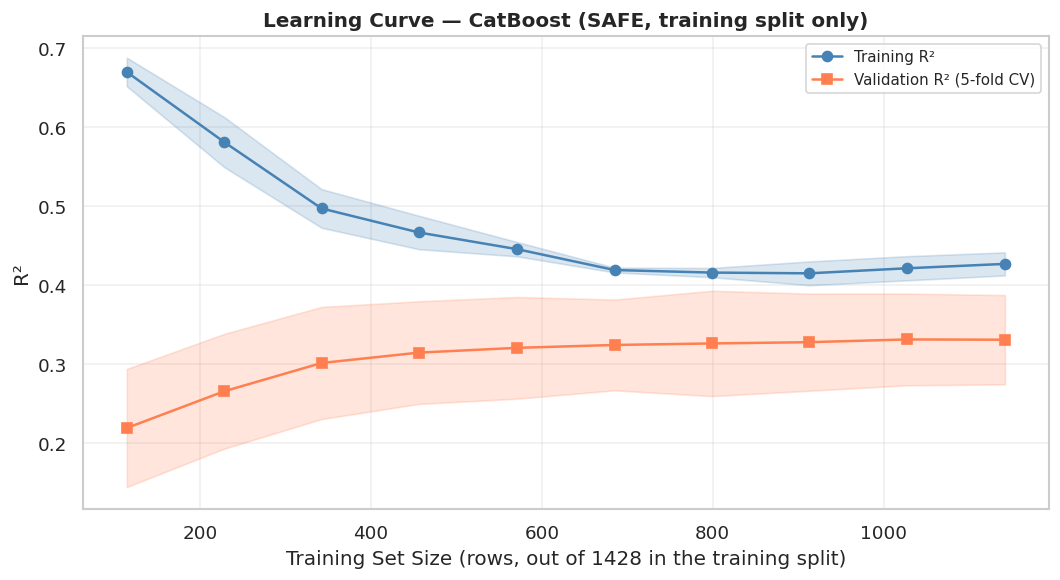


Validation R² at each training size (counts cannot exceed the training split size):
  n=  114  (  8.0% of training split)  R²=0.2188 ± 0.0748
  n=  228  ( 16.0% of training split)  R²=0.2653 ± 0.0727
  n=  342  ( 23.9% of training split)  R²=0.3012 ± 0.0710
  n=  456  ( 31.9% of training split)  R²=0.3143 ± 0.0650
  n=  571  ( 40.0% of training split)  R²=0.3204 ± 0.0644
  n=  685  ( 48.0% of training split)  R²=0.3240 ± 0.0575
  n=  799  ( 56.0% of training split)  R²=0.3259 ± 0.0667
  n=  913  ( 63.9% of training split)  R²=0.3275 ± 0.0615
  n= 1027  ( 71.9% of training split)  R²=0.3310 ± 0.0581
  n= 1142  ( 80.0% of training split)  R²=0.3307 ± 0.0565

✅ Curve has plateaued (ΔR²=0.0004 between last two points). Current training set size is sufficient.


In [23]:
# ── CELL 21: Learning Curve (Correct Sample Counts) ──────────────────────────
# FIX D: computed strictly on the TRAINING split (not the full dataset), so
# reported sample counts and percentages are internally consistent and can't
# exceed the training set size.

print(f'Running learning curve on the SAFE training split (n={len(X_train_safe_raw)})...')

lc_model = clone(primary_model)
train_sizes_abs, train_scores, val_scores = learning_curve(
    lc_model, X_train_safe_raw, y_train_reg,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=CONFIG['cv_folds'], scoring='r2', n_jobs=-1
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', label='Training R²')
ax.fill_between(train_sizes_abs, train_mean-train_std, train_mean+train_std, alpha=0.2, color='steelblue')
ax.plot(train_sizes_abs, val_mean, 's-', color='coral', label=f'Validation R² ({CONFIG["cv_folds"]}-fold CV)')
ax.fill_between(train_sizes_abs, val_mean-val_std, val_mean+val_std, alpha=0.2, color='coral')
ax.set_xlabel(f'Training Set Size (rows, out of {len(X_train_safe_raw)} in the training split)')
ax.set_ylabel('R²')
ax.set_title(f'Learning Curve — {primary_model_name} (SAFE, training split only)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{CONFIG["paths"]["figures_dir"]}/learning_curve.png', bbox_inches='tight'); plt.show()

print('\nValidation R² at each training size (counts cannot exceed the training split size):')
for n, vm, vs in zip(train_sizes_abs, val_mean, val_std):
    pct = n / len(X_train_safe_raw) * 100
    print(f'  n={int(n):>5}  ({pct:>5.1f}% of training split)  R²={vm:.4f} ± {vs:.4f}')

delta_last = abs(val_mean[-1] - val_mean[-2])
if delta_last < 0.005:
    print(f'\n✅ Curve has plateaued (ΔR²={delta_last:.4f} between last two points). '
          'Current training set size is sufficient.')
else:
    print(f'\n⚠️ Curve still rising (ΔR²={delta_last:.4f}). Note as a limitation — more data could help.')

MAE: 867.2ms  Median AE: 593.7ms
% within 200ms: 16.5%   % within 500ms: 43.7%
Mean residual (bias): -51.9ms

Error by LCP category:
                     mean  median     max  count
category                                        
Good                660.0   504.5  2856.0    264
Needs Improvement   616.3   539.9  2091.6     52
Poor               2519.2  1977.1  6685.8     41

Shapiro-Wilk p=0.000000 — residuals are non-normal


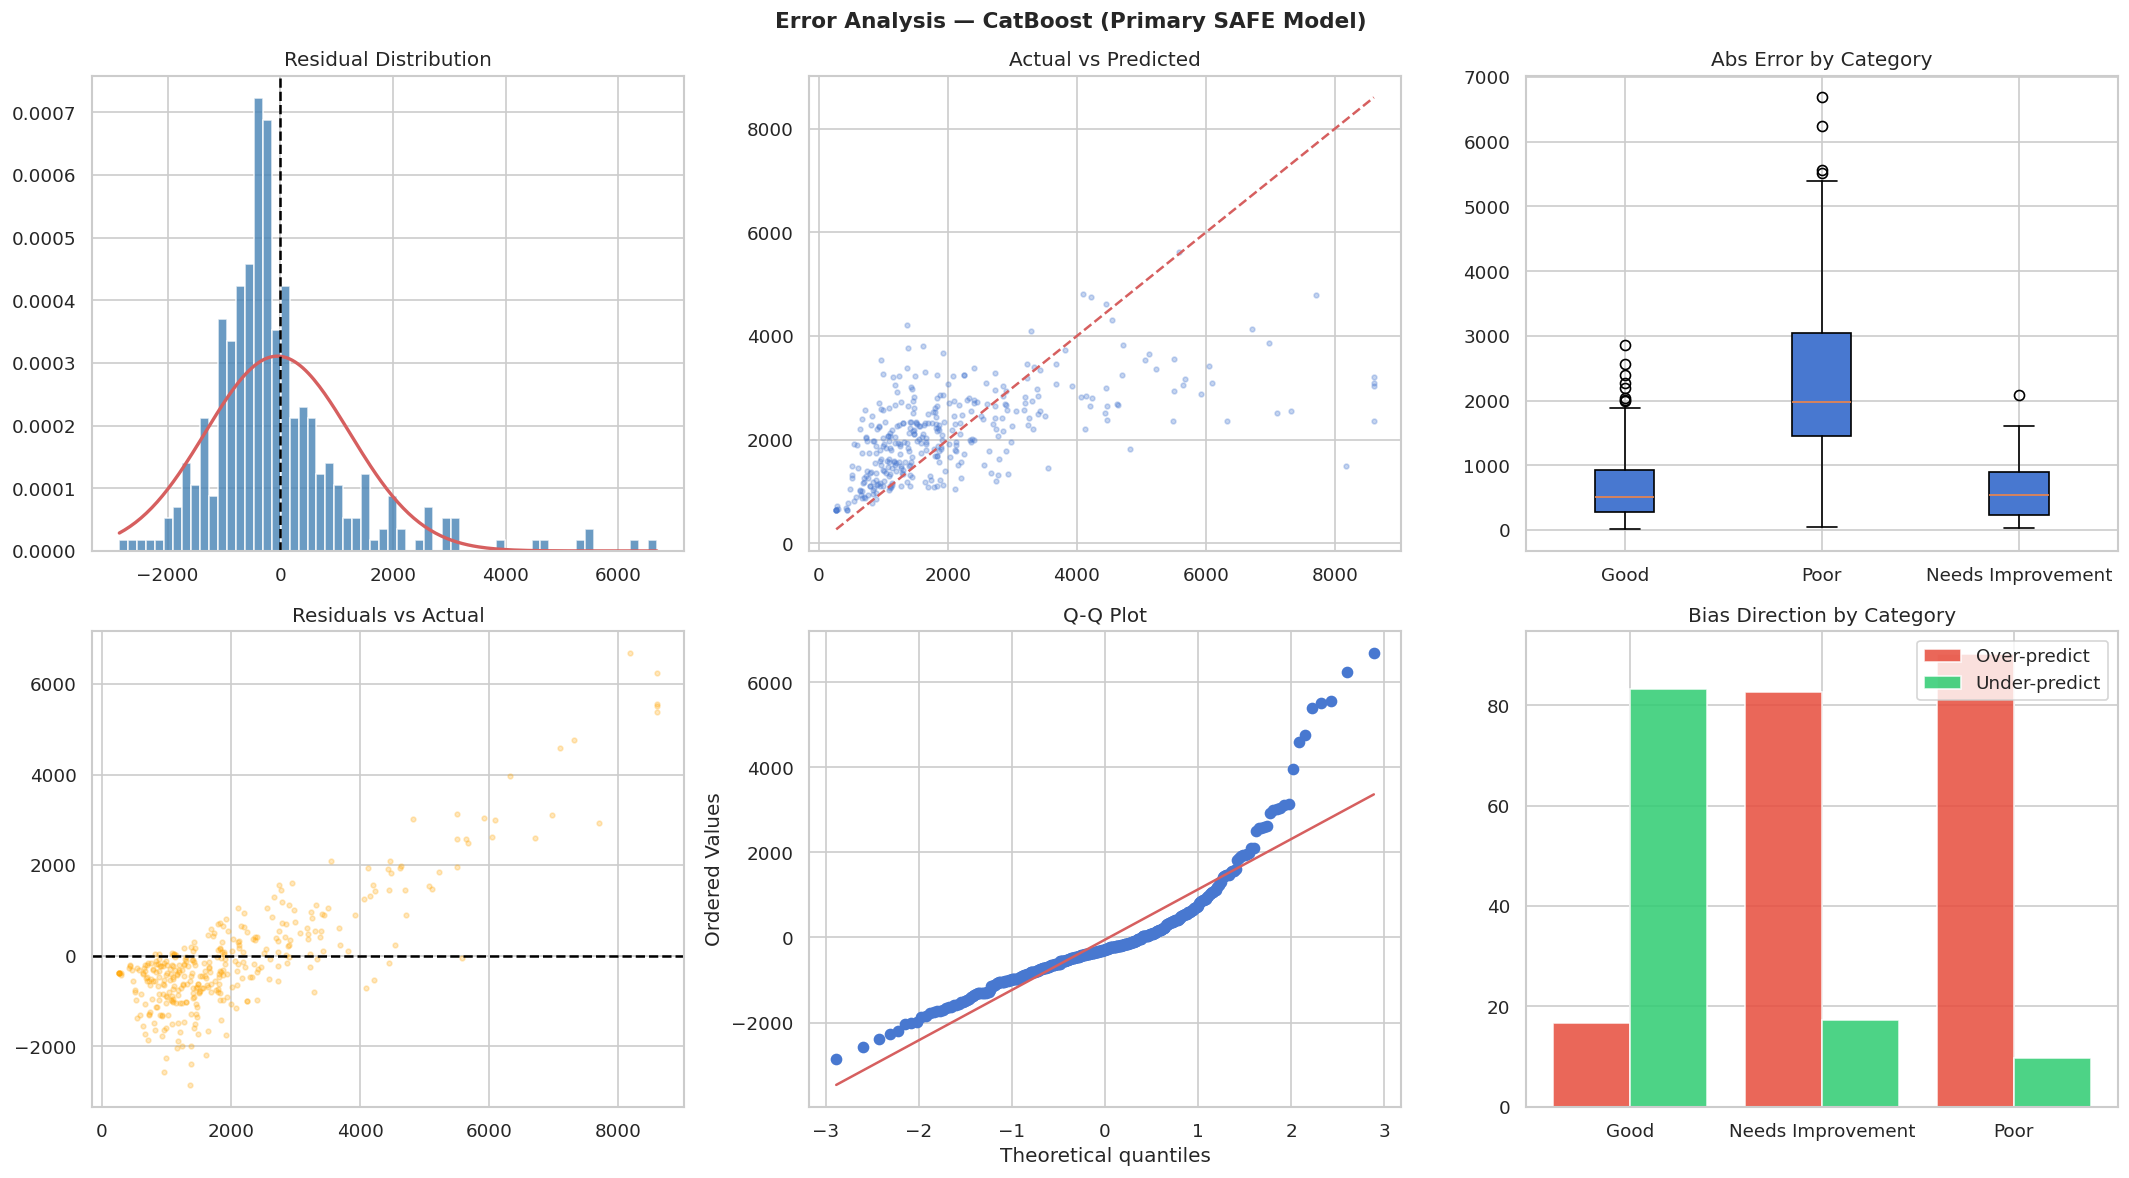


Worst-predicted URLs:
                              url      actual   predicted   abs_error
             https://www.ssrn.com 8177.180257 1491.382538 6685.797719
      https://www.sundancenow.com 8603.001976 2362.754522 6240.247454
              https://www.mgm.com 8603.001976 3039.104355 5563.897621
       https://www.tablespoon.com 8603.001976 3090.505835 5512.496141
          https://www.weather.com 8603.001976 3212.631942 5390.370034
           https://www.altair.com 7311.344318 2555.330473 4756.013845
         https://www.gofundme.com 7102.222571 2520.280799 4581.941771
https://www.globalforestwatch.org 6329.045722 2358.750132 3970.295590
            https://www.giphy.com 5496.936942 2360.298544 3136.638398
            https://www.wired.com 6971.434466 3864.624636 3106.809830


In [24]:
# ── CELL 22: Residual / Error Analysis for the Primary SAFE Model ───────────
residuals  = y_test_reg - y_pred_primary
abs_errors = np.abs(residuals)

error_df = pd.DataFrame({
    'url': df_clean.iloc[test_idx]['url'].values,
    'actual': y_test_reg, 'predicted': y_pred_primary,
    'abs_error': abs_errors, 'residual': residuals,
    'category': df_clean.iloc[test_idx]['LCP_Category'].values
})

print(f'MAE: {abs_errors.mean():.1f}ms  Median AE: {np.median(abs_errors):.1f}ms')
print(f'% within 200ms: {(abs_errors<200).mean()*100:.1f}%   % within 500ms: {(abs_errors<500).mean()*100:.1f}%')
print(f'Mean residual (bias): {residuals.mean():.1f}ms')

print('\nError by LCP category:')
print(error_df.groupby('category')['abs_error'].agg(['mean','median','max','count']).round(1))

_, p_sw = shapiro(residuals[:5000])
print(f'\nShapiro-Wilk p={p_sw:.6f} — residuals are {"approximately normal" if p_sw>0.05 else "non-normal"}')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0,0].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
xn = np.linspace(residuals.min(), residuals.max(), 200)
axes[0,0].plot(xn, stats.norm.pdf(xn, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0,0].axvline(0, color='black', linestyle='--'); axes[0,0].set_title('Residual Distribution')

axes[0,1].scatter(y_test_reg, y_pred_primary, alpha=0.3, s=8)
mn, mx = y_test_reg.min(), y_test_reg.max()
axes[0,1].plot([mn,mx],[mn,mx],'r--'); axes[0,1].set_title('Actual vs Predicted')

cats = error_df['category'].unique()
axes[0,2].boxplot([error_df[error_df['category']==c]['abs_error'].values for c in cats],
                  labels=cats, patch_artist=True)
axes[0,2].set_title('Abs Error by Category')

axes[1,0].scatter(error_df['actual'], error_df['residual'], alpha=0.25, s=8, color='orange')
axes[1,0].axhline(0, color='black', linestyle='--'); axes[1,0].set_title('Residuals vs Actual')

probplot(residuals, dist='norm', plot=axes[1,1]); axes[1,1].set_title('Q-Q Plot')

err_cat = error_df.groupby('category').apply(
    lambda g: pd.Series({'Over': (g['residual']>0).mean()*100, 'Under': (g['residual']<0).mean()*100})).reset_index()
x_c = np.arange(len(err_cat))
axes[1,2].bar(x_c-0.2, err_cat['Over'], 0.4, label='Over-predict', color='#e74c3c', alpha=0.85)
axes[1,2].bar(x_c+0.2, err_cat['Under'], 0.4, label='Under-predict', color='#2ecc71', alpha=0.85)
axes[1,2].set_xticks(x_c); axes[1,2].set_xticklabels(err_cat['category']); axes[1,2].legend()
axes[1,2].set_title('Bias Direction by Category')

plt.suptitle(f'Error Analysis — {primary_model_name} (Primary SAFE Model)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{CONFIG["paths"]["figures_dir"]}/error_analysis.png', bbox_inches='tight'); plt.show()

worst = error_df.sort_values('abs_error', ascending=False).head(10)
print('\nWorst-predicted URLs:'); print(worst[['url','actual','predicted','abs_error']].to_string(index=False))
error_df.to_csv(f'{CONFIG["paths"]["results_dir"]}/error_analysis.csv', index=False)

CLASSIFICATION (secondary) — Good / Needs Improvement / Poor
Class distribution (test): {0: np.int64(264), 1: np.int64(52), 2: np.int64(41)}
  Random Forest (balanced)     balanced F1-Macro=0.4839  SMOTE F1-Macro=0.5506
  XGBoost                      balanced F1-Macro=0.4518  SMOTE F1-Macro=0.5405
  LightGBM                     balanced F1-Macro=0.4836  SMOTE F1-Macro=0.5341

TABLE: Classification — class_weight=balanced
                   Model  Accuracy  F1-Weighted  F1-Macro  Precision-W  Recall-W
Random Forest (balanced)    0.7591       0.7147    0.4839       0.7072    0.7591
                LightGBM    0.7507       0.7169    0.4836       0.7050    0.7507
                 XGBoost    0.7423       0.7036    0.4518       0.6856    0.7423

TABLE: Classification — SMOTE (train-only)
                         Model  Accuracy  F1-Weighted  F1-Macro  Precision-W  Recall-W
Random Forest (balanced)+SMOTE    0.7227       0.7282    0.5506       0.7383    0.7227
                 XGBoost+SMOTE   

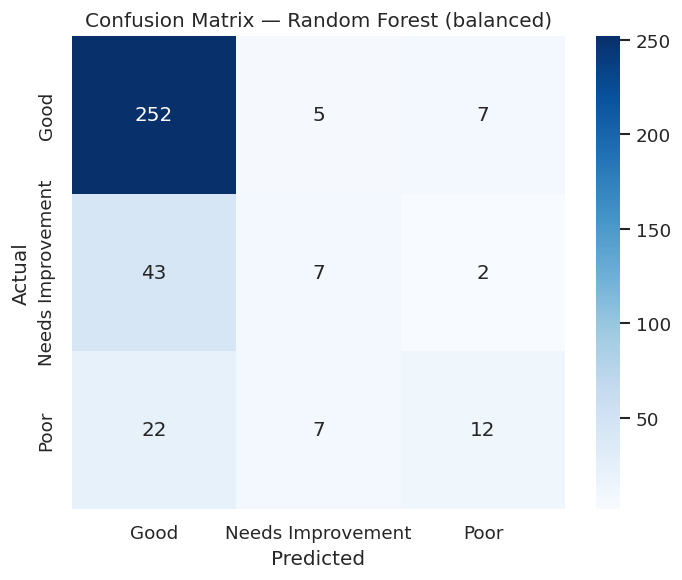

In [25]:
# ── CELL 23: Classification Branch — Secondary to Regression ────────────────
print('CLASSIFICATION (secondary) — Good / Needs Improvement / Poor')
print(f'Class distribution (test): {dict(pd.Series(y_test_clf).value_counts())}')

clf_models_list = [
    ('Random Forest (balanced)', RandomForestClassifier(n_estimators=200, random_state=CONFIG['seed'], n_jobs=-1, class_weight='balanced')),
    ('XGBoost', xgb.XGBClassifier(n_estimators=200, random_state=CONFIG['seed'], verbosity=0)),
    ('LightGBM', lgb.LGBMClassifier(n_estimators=200, random_state=CONFIG['seed'], verbose=-1)),
]

clf_results_balanced, clf_results_smote = [], []
clf_models_dict = {}
for name, model in clf_models_list:
    m1, y_pred1, metrics1 = eval_classifier(name, model, X_train_safe_raw, y_train_clf, X_test_safe_raw, y_test_clf)
    clf_results_balanced.append({'Model': name, **metrics1})
    clf_models_dict[name] = m1

    model_smote = copy.deepcopy(model)
    m2, y_pred2, metrics2 = eval_classifier(f'{name}+SMOTE', model_smote, X_train_smote, y_train_smote, X_test_safe_raw, y_test_clf)
    clf_results_smote.append({'Model': f'{name}+SMOTE', **metrics2})
    print(f'  {name:<28} balanced F1-Macro={metrics1["F1-Macro"]:.4f}  SMOTE F1-Macro={metrics2["F1-Macro"]:.4f}')

clf_df_balanced = pd.DataFrame(clf_results_balanced).sort_values('F1-Macro', ascending=False)
clf_df_smote    = pd.DataFrame(clf_results_smote).sort_values('F1-Macro', ascending=False)
best_clf_name   = clf_df_balanced.iloc[0]['Model']
best_clf_model  = clf_models_dict[best_clf_name]

print('\nTABLE: Classification — class_weight=balanced'); print(clf_df_balanced.to_string(index=False))
print('\nTABLE: Classification — SMOTE (train-only)');     print(clf_df_smote.to_string(index=False))
print(f'\n🏆 Best classifier: {best_clf_name}')

y_pred_best_clf = best_clf_model.predict(X_test_safe_raw)
print('\nPer-class report:')
print(classification_report(y_test_clf, y_pred_best_clf, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_test_clf, y_pred_best_clf)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(f'Confusion Matrix — {best_clf_name}')
plt.tight_layout(); plt.savefig(f'{CONFIG["paths"]["figures_dir"]}/confusion_matrix.png', bbox_inches='tight'); plt.show()

Computing SHAP values on the canonical primary model: CatBoost (SAFE)


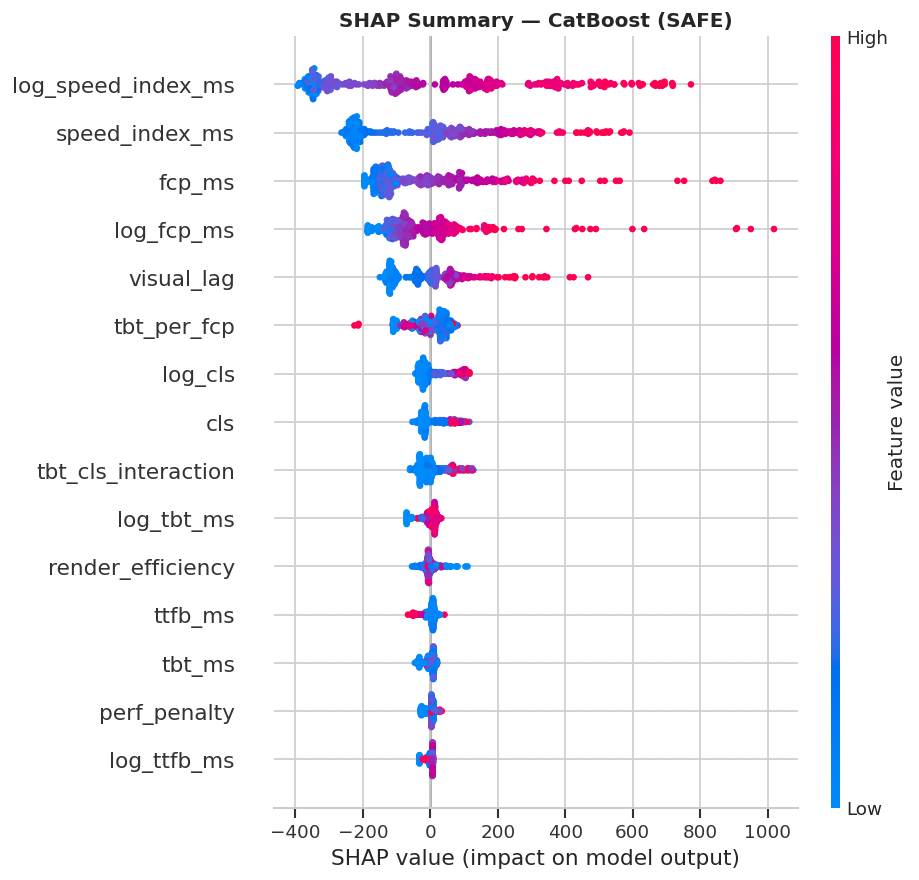


TABLE: SHAP Feature Importance (SAFE)
            Feature  Mean |SHAP|
 log_speed_index_ms   262.200862
     speed_index_ms   177.361467
             fcp_ms   140.500926
         log_fcp_ms    99.203466
         visual_lag    84.117298
        tbt_per_fcp    40.496772
            log_cls    33.205453
                cls    31.251920
tbt_cls_interaction    27.758849
         log_tbt_ms    14.523427
  render_efficiency    12.326397
            ttfb_ms    10.854111
             tbt_ms    10.604384
       perf_penalty     9.527283
        log_ttfb_ms     7.477364
       jank_density     5.885425
      network_share     4.342127


<Figure size 960x600 with 0 Axes>

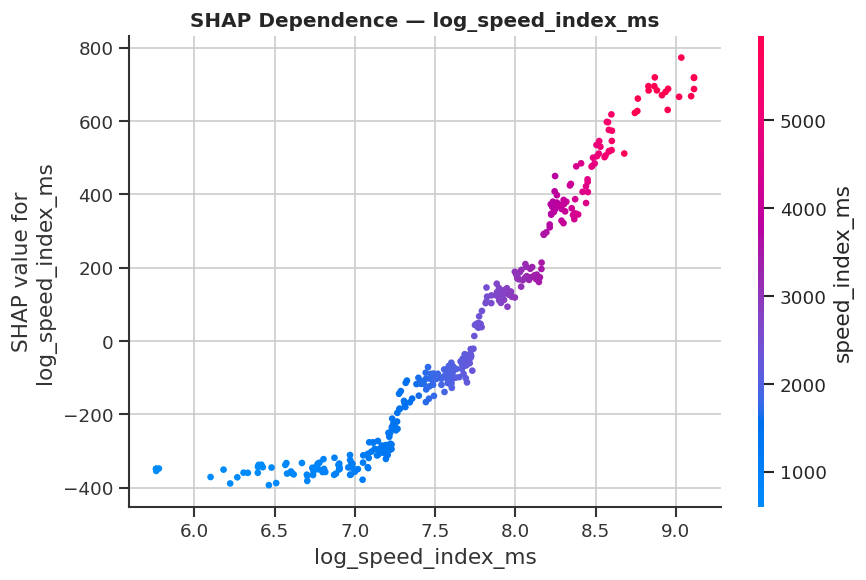

<Figure size 960x600 with 0 Axes>

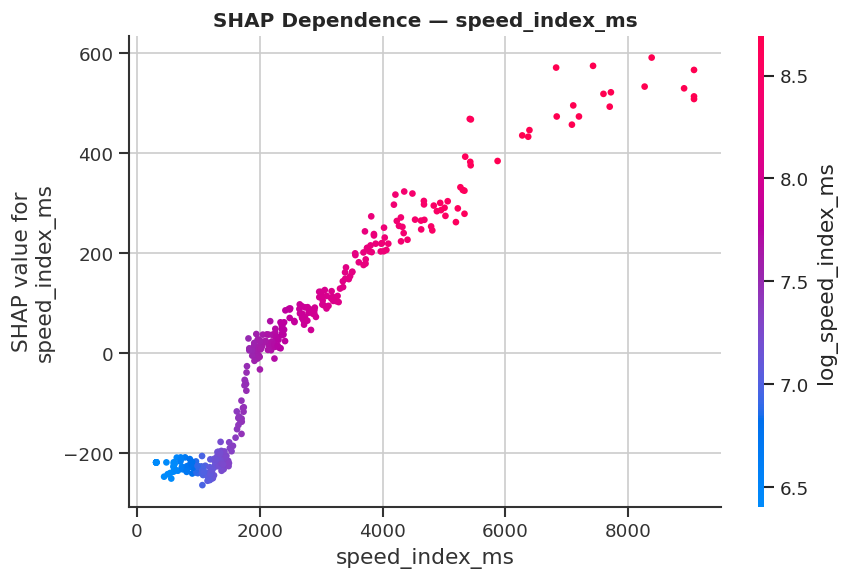

<Figure size 960x600 with 0 Axes>

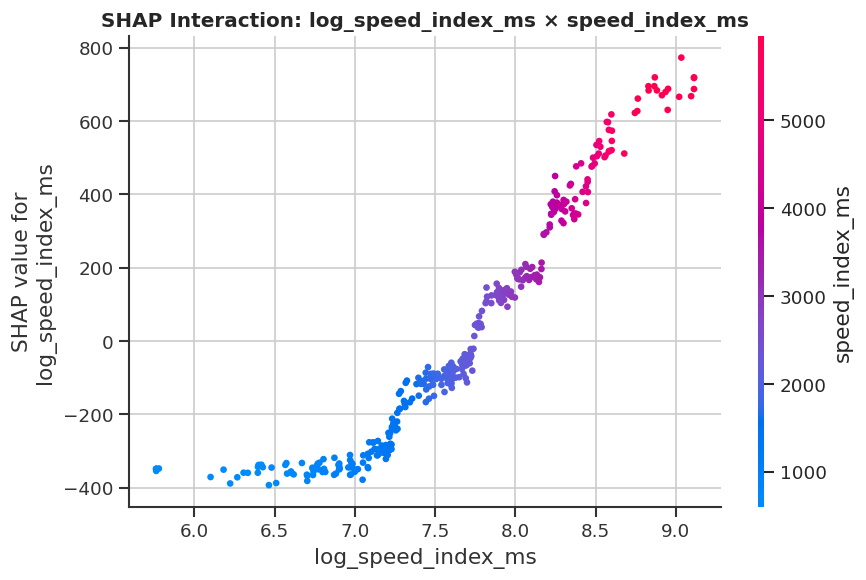


✅ SHAP analysis complete.


In [26]:
# ── CELL 24: SHAP Explainability — Primary SAFE Model ────────────────────────
print(f'Computing SHAP values on the canonical primary model: {primary_model_name} (SAFE)')

explainer = shap.TreeExplainer(primary_model)
shap_sample = X_test_safe_raw.sample(min(CONFIG['shap_sample_size'], len(X_test_safe_raw)), random_state=CONFIG['seed'])
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_sample, feature_names=valid_safe, plot_type='dot', show=False, max_display=15)
plt.title(f'SHAP Summary — {primary_model_name} (SAFE)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{CONFIG["paths"]["figures_dir"]}/shap_summary.png', bbox_inches='tight'); plt.show()

mean_shap = pd.DataFrame({'Feature': valid_safe, 'Mean |SHAP|': np.abs(shap_values).mean(axis=0)}) \
              .sort_values('Mean |SHAP|', ascending=False)
print('\nTABLE: SHAP Feature Importance (SAFE)'); print(mean_shap.to_string(index=False))

for i in range(min(2, len(mean_shap))):
    top_feat = mean_shap.iloc[i]['Feature']
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(top_feat, shap_values, shap_sample, feature_names=valid_safe, show=False)
    plt.title(f'SHAP Dependence — {top_feat}', fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{CONFIG["paths"]["figures_dir"]}/shap_dependence_{i+1}.png', bbox_inches='tight'); plt.show()

if len(mean_shap) >= 2:
    f1, f2 = mean_shap.iloc[0]['Feature'], mean_shap.iloc[1]['Feature']
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(f1, shap_values, shap_sample, interaction_index=f2, feature_names=valid_safe, show=False)
    plt.title(f'SHAP Interaction: {f1} × {f2}', fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{CONFIG["paths"]["figures_dir"]}/shap_interaction.png', bbox_inches='tight'); plt.show()

mean_shap.to_csv(f'{CONFIG["paths"]["results_dir"]}/shap_importance.csv', index=False)
print('\n✅ SHAP analysis complete.')

In [27]:
# ── Q2_PATCH: Item H - SHAP Attribution Stability Across Seeds ──────────────
# Recomputes SHAP mean(|value|) feature rankings on independently drawn
# random subsamples (different seeds) of the held-out test set and checks
# whether the TOP-5 feature ranking is stable, rather than presenting a
# single, potentially seed-dependent run as if it were definitive.

stability_rankings = {}
for s in CONFIG['seeds_for_stability']:
    sample_s = X_test_safe_raw.sample(min(CONFIG['shap_sample_size'], len(X_test_safe_raw)), random_state=s)
    sv_s = explainer.shap_values(sample_s)
    rank_s = pd.Series(np.abs(sv_s).mean(axis=0), index=valid_safe).sort_values(ascending=False)
    stability_rankings[s] = rank_s

top5_by_seed = {s: r.head(5).index.tolist() for s, r in stability_rankings.items()}
reference_top5 = mean_shap.head(5)['Feature'].tolist()

overlap_fracs, spearman_rhos = [], []
for s, r in stability_rankings.items():
    overlap = len(set(r.head(5).index) & set(reference_top5)) / 5
    overlap_fracs.append(overlap)
    common = [f for f in valid_safe]
    rho = pd.Series(r[common]).rank().corr(mean_shap.set_index('Feature').loc[common, 'Mean |SHAP|'].rank(), method='pearson')
    spearman_rhos.append(rho)

print('='*75)
print('ITEM H: SHAP STABILITY ACROSS RANDOM SUBSAMPLES')
print('='*75)
for s in CONFIG['seeds_for_stability']:
    print(f'  seed={s:<4} top-5: {top5_by_seed[s]}')
print(f'\nReference (primary) top-5 : {reference_top5}')
print(f'Mean top-5 overlap fraction : {np.mean(overlap_fracs):.2f}  (1.0 = identical top-5 every time)')
print(f'Mean full-ranking rank-correlation : {np.mean(spearman_rhos):.3f}')

SHAP_STABILITY_SUMMARY = {
    'mean_top5_overlap': round(float(np.mean(overlap_fracs)), 3),
    'min_top5_overlap': round(float(np.min(overlap_fracs)), 3),
    'mean_rank_correlation': round(float(np.mean(spearman_rhos)), 3),
    'stable': bool(np.mean(overlap_fracs) >= 0.8),
}
if SHAP_STABILITY_SUMMARY['stable']:
    print('\n✅ Top feature drivers are stable across resamples (mean overlap ≥ 0.8).')
else:
    print('\n⚠️ Top-5 ranking is NOT fully stable across resamples — report this uncertainty')
    print('   explicitly in the SHAP/interpretability discussion rather than treating the')
    print('   single-run ranking as definitive.')

pd.DataFrame(SHAP_STABILITY_SUMMARY, index=[0]).to_csv(f'{CONFIG["paths"]["results_dir"]}/shap_stability_summary.csv', index=False)


ITEM H: SHAP STABILITY ACROSS RANDOM SUBSAMPLES
  seed=1    top-5: ['log_speed_index_ms', 'speed_index_ms', 'fcp_ms', 'log_fcp_ms', 'visual_lag']
  seed=7    top-5: ['log_speed_index_ms', 'speed_index_ms', 'fcp_ms', 'log_fcp_ms', 'visual_lag']
  seed=21   top-5: ['log_speed_index_ms', 'speed_index_ms', 'fcp_ms', 'log_fcp_ms', 'visual_lag']
  seed=42   top-5: ['log_speed_index_ms', 'speed_index_ms', 'fcp_ms', 'log_fcp_ms', 'visual_lag']
  seed=99   top-5: ['log_speed_index_ms', 'speed_index_ms', 'fcp_ms', 'log_fcp_ms', 'visual_lag']

Reference (primary) top-5 : ['log_speed_index_ms', 'speed_index_ms', 'fcp_ms', 'log_fcp_ms', 'visual_lag']
Mean top-5 overlap fraction : 1.00  (1.0 = identical top-5 every time)
Mean full-ranking rank-correlation : 1.000

✅ Top feature drivers are stable across resamples (mean overlap ≥ 0.8).


Ablation baseline: CatBoost (SAFE), Test R²=0.3303

== 1) Permutation Importance (primary metric) ==
            Feature  Importance Mean  Importance Std
 log_speed_index_ms         0.085570        0.017534
     speed_index_ms         0.049018        0.012856
             fcp_ms         0.042278        0.008608
         log_fcp_ms         0.035402        0.006550
        tbt_per_fcp         0.014636        0.004514
                cls         0.006108        0.003693
            log_cls         0.004047        0.002400
         log_tbt_ms         0.003232        0.001868
tbt_cls_interaction         0.003162        0.002085
             tbt_ms         0.002549        0.001288
         visual_lag         0.002301        0.006321
      network_share         0.001304        0.000558
       jank_density         0.001014        0.001511
            ttfb_ms         0.000302        0.001059
        log_ttfb_ms         0.000171        0.000728
       perf_penalty        -0.001199        0.00122

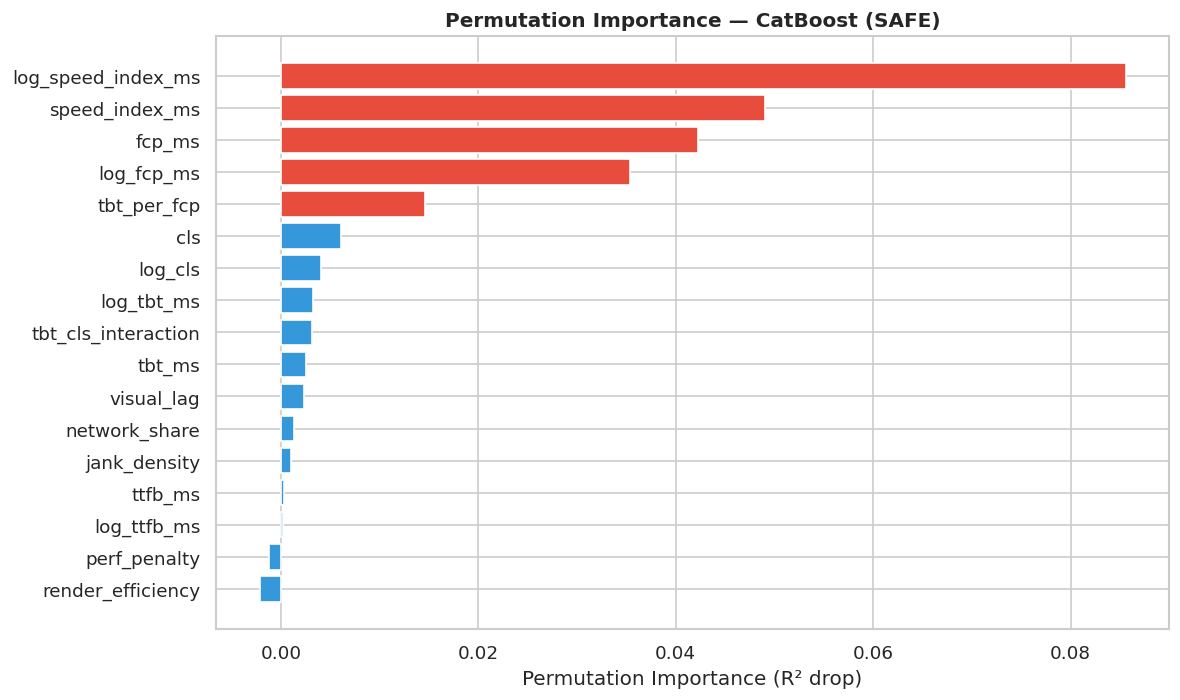

In [28]:
# ── CELL 25: Permutation Importance + Retrain Leave-One-Out Ablation ────────
# FIX E: primary ablation evidence is (1) permutation importance and
# (2) retrain-without-feature. Zero-out ablation is kept only as a labeled
# supplementary check, since it can push samples off-distribution.

print(f'Ablation baseline: {primary_model_name} (SAFE), Test R²={r2_score(y_test_reg, y_pred_primary):.4f}')

print('\n== 1) Permutation Importance (primary metric) ==')
perm = permutation_importance(primary_model, X_test_safe_raw, y_test_reg,
                               scoring='r2', n_repeats=20, random_state=CONFIG['seed'], n_jobs=-1)
perm_df = pd.DataFrame({'Feature': valid_safe, 'Importance Mean': perm.importances_mean,
                         'Importance Std': perm.importances_std}).sort_values('Importance Mean', ascending=False)
print(perm_df.to_string(index=False))

top_features = perm_df.head(5)['Feature'].tolist()
print(f'\n== 2) Retrain leave-one-feature-out ablation for top-5 permutation features: {top_features} ==')
retrain_rows = []
baseline_r2 = r2_score(y_test_reg, y_pred_primary)
for feat in top_features:
    reduced_feats = [f for f in valid_safe if f != feat]
    model_wo = clone(primary_model)
    model_wo.fit(X_train_safe_raw[reduced_feats], y_train_reg)
    r2_wo = r2_score(y_test_reg, model_wo.predict(X_test_safe_raw[reduced_feats]))
    retrain_rows.append({'Feature removed': feat, 'R² (retrained without)': round(r2_wo, 4),
                          'R² drop': round(baseline_r2 - r2_wo, 4)})
retrain_ablation_df = pd.DataFrame(retrain_rows).sort_values('R² drop', ascending=False)
print(retrain_ablation_df.to_string(index=False))

print('\n== 3) SUPPLEMENTARY ONLY: zero-out ablation (does not retrain, may be off-distribution) ==')
zeroout_rows = []
for feat in valid_safe:
    X_abl = X_test_safe_raw.copy(); X_abl[feat] = 0
    r2_abl = r2_score(y_test_reg, primary_model.predict(X_abl))
    zeroout_rows.append({'Feature': feat, 'R² without (zeroed)': round(r2_abl,4), 'R² drop': round(baseline_r2 - r2_abl, 4)})
zeroout_df = pd.DataFrame(zeroout_rows).sort_values('R² drop', ascending=False)
print(zeroout_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 0.01 else '#3498db' for v in perm_df['Importance Mean']]
ax.barh(perm_df['Feature'][::-1], perm_df['Importance Mean'][::-1], color=colors[::-1])
ax.set_xlabel('Permutation Importance (R² drop)')
ax.set_title(f'Permutation Importance — {primary_model_name} (SAFE)', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{CONFIG["paths"]["figures_dir"]}/ablation_permutation.png', bbox_inches='tight'); plt.show()

perm_df.to_csv(f'{CONFIG["paths"]["results_dir"]}/permutation_importance.csv', index=False)
retrain_ablation_df.to_csv(f'{CONFIG["paths"]["results_dir"]}/retrain_ablation.csv', index=False)
zeroout_df.to_csv(f'{CONFIG["paths"]["results_dir"]}/zeroout_ablation_supplementary.csv', index=False)

In [29]:
# ── CELL 26: Statistical Testing — Model Comparisons ─────────────────────────
# Q2_PATCH: Item F. The original single-test-split Wilcoxon test below is
# RETAINED as a supplementary, more granular diagnostic, but it is no longer
# the primary significance evidence: it treats n_test instance residuals as
# independent replicates, which overstates the number of independent
# evaluation units. The primary evidence is now the fold-level paired test
# further down this cell, run on GroupKFold fold-level R² scores (5
# genuinely independent replicates per model).
tuned_keys = [k for k in EXPERIMENTS if k.startswith('reg_safe_tuned_')]
tuned_by_r2 = sorted(tuned_keys, key=lambda k: EXPERIMENTS[k]['metrics']['R²'], reverse=True)
top3_keys = tuned_by_r2[:3]
print(f'Top-3 tuned SAFE models: {[EXPERIMENTS[k]["model_name"] for k in top3_keys]}')

pairs = list(combinations(top3_keys, 2))
n_comparisons = len(pairs) + 2   # + tuned-vs-untuned + SAFE-vs-FULL comparisons below
wilcoxon_rows = []

for k1, k2 in pairs:
    e1 = np.abs(y_test_reg - EXPERIMENTS[k1]['y_pred_test'])
    e2 = np.abs(y_test_reg - EXPERIMENTS[k2]['y_pred_test'])
    stat, p_raw = wilcoxon(e1, e2)
    wilcoxon_rows.append({'Comparison': f"{EXPERIMENTS[k1]['model_name']} vs {EXPERIMENTS[k2]['model_name']}",
                           'Mean |error| delta': round(e1.mean() - e2.mean(), 2),
                           'Statistic': round(stat, 2), 'p_raw': round(p_raw, 6),
                           'p_bonf': round(min(p_raw * n_comparisons, 1.0), 6)})

# Tuned vs baseline (untuned) for the primary model
baseline_key = f'reg_safe_baseline_{primary_model_name}'
if baseline_key in EXPERIMENTS:
    e_tuned = np.abs(y_test_reg - y_pred_primary)
    e_base  = np.abs(y_test_reg - EXPERIMENTS[baseline_key]['y_pred_test'])
    stat, p_raw = wilcoxon(e_tuned, e_base)
    wilcoxon_rows.append({'Comparison': f'{primary_model_name} tuned vs untuned',
                           'Mean |error| delta': round(e_tuned.mean() - e_base.mean(), 2),
                           'Statistic': round(stat, 2), 'p_raw': round(p_raw, 6),
                           'p_bonf': round(min(p_raw * n_comparisons, 1.0), 6)})

# SAFE primary vs FULL diagnostic (same held-out samples, same model family)
full_key = f'reg_full_diagnostic_{primary_model_name}'
if full_key in EXPERIMENTS:
    e_safe = np.abs(y_test_reg - y_pred_primary)
    e_full = np.abs(y_test_reg - EXPERIMENTS[full_key]['y_pred_test'])
    stat, p_raw = wilcoxon(e_safe, e_full)
    wilcoxon_rows.append({'Comparison': f'{primary_model_name} SAFE vs FULL (diagnostic)',
                           'Mean |error| delta': round(e_safe.mean() - e_full.mean(), 2),
                           'Statistic': round(stat, 2), 'p_raw': round(p_raw, 6),
                           'p_bonf': round(min(p_raw * n_comparisons, 1.0), 6)})

wx_df = pd.DataFrame(wilcoxon_rows)
wx_df['Significant (α=0.05, Bonferroni)'] = wx_df['p_bonf'] < 0.05
print('\nTABLE (SUPPLEMENTARY, instance-level residual diagnostic \u2014 do NOT copy into paper as the primary significance evidence):')
print(wx_df.to_string(index=False))
print('\nInterpretation note: statistically significant does not imply practically large;')
print('always report the mean |error| delta alongside the p-value.')
print('NOTE: the table above pseudo-replicates on n_test single-split instance residuals.')
print('It is retained as a supplementary, more granular diagnostic only \u2014 see the fold-level')
print('table below for the PRIMARY significance evidence to report in the paper.')
wx_df.to_csv(f'{CONFIG["paths"]["results_dir"]}/wilcoxon_tests_instance_level_supplementary.csv', index=False)

# ── Q2_PATCH: Item F PRIMARY — fold-level paired significance testing ───────
print('\n' + '='*75)
print('ITEM F (PRIMARY \u2014 this is the significance evidence to report in the paper): FOLD-LEVEL PAIRED WILCOXON TESTS')
print('='*75)
top3_names = [EXPERIMENTS[k]['model_name'] for k in top3_keys]
fold_scores_by_model = {}
for k in top3_keys:
    mname = EXPERIMENTS[k]['model_name']
    mobj = clone(EXPERIMENTS[k]['model_obj'])
    # Q2_PATCH FIX (Item B, canonical): fold-level scores for the significance
    # test must come from the SAME fold-safe SAFE pipeline as Cell 18's
    # primary CV, not the old globally-winsorized X_safe_raw.
    fold_safe_pipeline_k = SkPipeline([
        ('safe_features', SafeFeatureBuilder()),
        ('regressor', mobj),
    ])
    fold_scores_by_model[mname] = cross_val_score(fold_safe_pipeline_k, base_raw_df, y_reg_raw, cv=kf5,
                                                    groups=groups_raw, scoring='r2', n_jobs=-1)
fold_scores_by_model[primary_model_name] = PRIMARY_MODEL_CV_FOLDS  # reuse Cell 18 computation, same folds

fold_pairs = list(combinations(set(fold_scores_by_model.keys()), 2))
n_fold_comparisons = max(len(fold_pairs), 1)
fold_wilcoxon_rows = []
for m1, m2 in fold_pairs:
    s1, s2 = fold_scores_by_model[m1], fold_scores_by_model[m2]
    try:
        stat, p_raw = wilcoxon(s1, s2)
    except ValueError:
        stat, p_raw = float('nan'), 1.0  # identical scores / too few folds to compute
    fold_wilcoxon_rows.append({'Comparison': f'{m1} vs {m2}',
                                'Mean R² delta (fold-level)': round(s1.mean() - s2.mean(), 4),
                                'Statistic': stat, 'p_raw': round(p_raw, 6),
                                'p_bonf': round(min(p_raw * n_fold_comparisons, 1.0), 6)})
fold_wx_df = pd.DataFrame(fold_wilcoxon_rows)
if not fold_wx_df.empty:
    fold_wx_df['Significant (α=0.05, Bonferroni)'] = fold_wx_df['p_bonf'] < 0.05
print(fold_wx_df.to_string(index=False) if not fold_wx_df.empty else '  (not enough fold-level replicates to run a test)')
print('\nn per comparison = CV fold count (5), i.e. genuinely independent evaluation units,')
print('unlike the instance-level test above which pseudo-replicates on n_test residuals.')
fold_wx_df.to_csv(f'{CONFIG["paths"]["results_dir"]}/wilcoxon_tests_foldlevel_primary.csv', index=False)

Top-3 tuned SAFE models: ['CatBoost', 'LightGBM', 'XGBoost']

TABLE (SUPPLEMENTARY, instance-level residual diagnostic — do NOT copy into paper as the primary significance evidence):
                        Comparison  Mean |error| delta  Statistic    p_raw   p_bonf  Significant (α=0.05, Bonferroni)
              CatBoost vs LightGBM               -6.95    30187.0 0.365852 1.000000                             False
               CatBoost vs XGBoost              -25.70    25613.0 0.001161 0.005804                              True
               LightGBM vs XGBoost              -18.75    25194.5 0.000535 0.002673                              True
         CatBoost tuned vs untuned              -20.94    31939.0 0.994889 1.000000                             False
CatBoost SAFE vs FULL (diagnostic)              655.23     4230.0 0.000000 0.000000                              True

Interpretation note: statistically significant does not imply practically large;
always report the mean |err

In [30]:
# ── Q2_PATCH: Item M - Scope & Threats to Validity (explicit block) ─────────
THREATS_TO_VALIDITY = {
    'measurement_environment': 'Synthetic, lab-based Lighthouse desktop audits, NOT real-user monitoring (RUM). '
        'Findings characterize lab-measured diagnostic-to-LCP relationships and may not transfer 1:1 to field data (e.g. CrUX).',
    'device_scope': 'Desktop-only audits. Mobile network/CPU throttling profiles were not evaluated; '
        'generalization to mobile LCP behaviour is NOT claimed.',
    'collection_window': f'{(df_raw["timestamp"].max()-df_raw["timestamp"].min())/3600:.1f} hours, '
        'a single short window. Chronology-based checks (Cell 19 / Item I) test order-sensitivity within this '
        'window only, not long-term temporal drift.',
    'network_topology': 'Single machine, single network path (see DATASET_META, Cell 4). '
        'Results may not generalize across network conditions, geographies, or CDNs.',
    'url_sampling': 'URLs drawn from a top-ranked domain list (see DATASET_META); sampling frame bias '
        'toward high-traffic/well-optimized sites is possible and not corrected for.',
    'aggregation': f'{CONFIG["min_runs_per_url"]} runs per URL averaged to reduce measurement noise (Cell 6-7); '
        'run-to-run LCP variability (Cell 6) is itself a source of residual label noise in the target.',
    'winsorization': 'Outlier capping at the 1st/99th percentile is a fixed-rule cleaning step; see Item B '
        'robustness check for a quantified comparison against train-only bounds.',
    'sample_size': f'{len(df_clean)} unique-URL rows after aggregation and filtering — modest for deep-learning-scale '
        'claims; results are reported with bootstrap and CV confidence intervals throughout to reflect this.',
}
print('='*75)
print('THREATS TO VALIDITY (Item M) — for manuscript Discussion / Limitations section')
print('='*75)
for k, v in THREATS_TO_VALIDITY.items():
    print(f'\n[{k}]')
    print(f'  {v}')

pd.DataFrame([{'item': k, 'statement': v} for k, v in THREATS_TO_VALIDITY.items()]).to_csv(
    f'{CONFIG["paths"]["results_dir"]}/threats_to_validity.csv', index=False)
print('\n✅ Threats-to-validity block exported to results/threats_to_validity.csv')


THREATS TO VALIDITY (Item M) — for manuscript Discussion / Limitations section

[measurement_environment]
  Synthetic, lab-based Lighthouse desktop audits, NOT real-user monitoring (RUM). Findings characterize lab-measured diagnostic-to-LCP relationships and may not transfer 1:1 to field data (e.g. CrUX).

[device_scope]
  Desktop-only audits. Mobile network/CPU throttling profiles were not evaluated; generalization to mobile LCP behaviour is NOT claimed.

[collection_window]
  56.5 hours, a single short window. Chronology-based checks (Cell 19 / Item I) test order-sensitivity within this window only, not long-term temporal drift.

[network_topology]
  Single machine, single network path (see DATASET_META, Cell 4). Results may not generalize across network conditions, geographies, or CDNs.

[url_sampling]
  URLs drawn from a top-ranked domain list (see DATASET_META); sampling frame bias toward high-traffic/well-optimized sites is possible and not corrected for.

[aggregation]
  3 runs 

In [31]:
# ── CELL 27: Final Results Export — Manuscript-Ready Artifacts ──────────────
# Q2_PATCH: Items N, O, P.
#  - Item N: adds a reproducibility package (config, seeds, feature lists,
#    split definitions/URLs, library versions) as JSON/CSV under
#    CONFIG['paths']['reproducibility_dir'].
#  - Item O: the seed audit below lists every seeded object in the notebook
#    so a reviewer can verify determinism at a glance instead of grepping.
#  - Item P: every file written in this cell is the CANONICAL, manuscript-
#    facing artifact. Manuscript tables/figures must be built FROM these
#    files, not retyped from console output.
import joblib

# Tables
reg_df_safe_tuned = experiments_to_dataframe(task='regression', feature_set='SAFE')
reg_df_safe_tuned = reg_df_safe_tuned[reg_df_safe_tuned['tuned']].sort_values('R²', ascending=False)
reg_df_safe_tuned.to_csv(f'{CONFIG["paths"]["results_dir"]}/regression_tuned_safe.csv', index=False)
reg_df_safe_baseline.to_csv(f'{CONFIG["paths"]["results_dir"]}/regression_baseline_safe.csv', index=False)
cv_df.to_csv(f'{CONFIG["paths"]["results_dir"]}/cv_results.csv', index=False)
compare_df.to_csv(f'{CONFIG["paths"]["results_dir"]}/safe_vs_full_comparison.csv', index=False)
clf_df_balanced.to_csv(f'{CONFIG["paths"]["results_dir"]}/classification_balanced.csv', index=False)
clf_df_smote.to_csv(f'{CONFIG["paths"]["results_dir"]}/classification_smote.csv', index=False)
tuning_df.to_csv(f'{CONFIG["paths"]["results_dir"]}/tuning_summary.csv', index=False)
pd.DataFrame([robustness_summary]).to_csv(f'{CONFIG["paths"]["results_dir"]}/robustness_summary.csv', index=False)

# Models
joblib.dump(primary_model, f'{CONFIG["paths"]["models_dir"]}/primary_model_{primary_model_name.lower()}.pkl')
for mname, m in tuned_models_safe.items():
    joblib.dump(m, f'{CONFIG["paths"]["models_dir"]}/tuned_{mname.lower()}.pkl')
joblib.dump(scaler_safe, f'{CONFIG["paths"]["models_dir"]}/scaler_safe.pkl')
joblib.dump(canonical_safe_builder, f'{CONFIG["paths"]["models_dir"]}/canonical_safe_feature_builder.pkl')  # Q2_PATCH Item B: fold-safe SAFE pipeline, fit on train split only
joblib.dump(le, f'{CONFIG["paths"]["models_dir"]}/label_encoder.pkl')

# ---- Item N/O: reproducibility package -------------------------------------
seed_audit = {
    'global_seed': CONFIG['seed'],
    'stability_seeds': CONFIG['seeds_for_stability'],
    'group_split_seed': CONFIG['seed'],           # GroupShuffleSplit (Cell 13)
    'kfold_seed': 'n/a (GroupKFold is deterministic given fold count + row order)',
    'tuning_seed': CONFIG['seed'],                 # RandomizedSearchCV (Cell 16)
    'bootstrap_seed': CONFIG['seed'],              # bootstrap_ci() default (Cell 14)
    'smote_seed': CONFIG['seed'],                  # SMOTE (Cell 13)
    'shap_sample_seed': CONFIG['seed'],            # SHAP sampling (Cell 24)
    'shap_stability_seeds': CONFIG['seeds_for_stability'],  # Item H
}
with open(f'{CONFIG["paths"]["reproducibility_dir"]}/seed_audit.json', 'w') as f:
    json.dump(seed_audit, f, indent=2)

with open(f'{CONFIG["paths"]["reproducibility_dir"]}/config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)

feature_lists = {
    'FEATURE_SAFE': FEATURE_SAFE,
    'FEATURE_FULL': FEATURE_FULL,
    'valid_safe_used': valid_safe,
    'valid_full_used': valid_full,
    'safe_winsorization_policy': 'Q2_PATCH Item B (canonical): fold-safe/train-only. '
        'Bounds are fit on the training split (or training fold, inside CV) only, via SafeFeatureBuilder, '
        'never on the full pre-split dataset.',
}
with open(f'{CONFIG["paths"]["reproducibility_dir"]}/feature_lists.json', 'w') as f:
    json.dump(feature_lists, f, indent=2)

split_definition = {
    'train_urls': sorted(list(train_urls)),
    'test_urls': sorted(list(test_urls)),
    'n_train': len(train_urls),
    'n_test': len(test_urls),
    'split_method': 'GroupShuffleSplit, group=url, test_size=%.2f, random_state=%d' % (CONFIG['test_size'], CONFIG['seed']),
}
with open(f'{CONFIG["paths"]["reproducibility_dir"]}/split_definition.json', 'w') as f:
    json.dump(split_definition, f, indent=2)

model_selection_summary = {
    'primary_model_key': PRIMARY_REGRESSION_MODEL_KEY,
    'primary_model_name': primary_model_name,
    'selection_rule': 'Item L: highest mean R² among tuned SAFE models under a fixed RandomizedSearchCV '
                       f'budget (n_iter={CONFIG["tuning_n_iter"]}, cv={CONFIG["tuning_cv"]}); see Cell 17.',
    'primary_hyperparams': PRIMARY_REGRESSION_ARTIFACT.get('hyperparams'),
    'primary_test_r2': PRIMARY_REGRESSION_ARTIFACT['metrics']['R²'],
}
with open(f'{CONFIG["paths"]["reproducibility_dir"]}/model_selection_summary.json', 'w') as f:
    json.dump(model_selection_summary, f, indent=2, default=str)

import sklearn, scipy, xgboost as _xgb_v, lightgbm as _lgb_v
try:
    import catboost as _cb_v
    cb_version = _cb_v.__version__
except Exception:
    cb_version = 'unknown'
library_versions = {
    'python_pandas': pd.__version__, 'numpy': np.__version__, 'scikit_learn': sklearn.__version__,
    'scipy': scipy.__version__, 'xgboost': _xgb_v.__version__, 'lightgbm': _lgb_v.__version__,
    'catboost': cb_version, 'shap': shap.__version__,
}
with open(f'{CONFIG["paths"]["reproducibility_dir"]}/library_versions.json', 'w') as f:
    json.dump(library_versions, f, indent=2)

# Item B / H / K patch-derived summaries, exported alongside for full traceability
with open(f'{CONFIG["paths"]["reproducibility_dir"]}/item_B_robustness.json', 'w') as f:
    json.dump(ITEM_B_ROBUSTNESS, f, indent=2)
with open(f'{CONFIG["paths"]["reproducibility_dir"]}/item_H_shap_stability.json', 'w') as f:
    json.dump(SHAP_STABILITY_SUMMARY, f, indent=2)
with open(f'{CONFIG["paths"]["reproducibility_dir"]}/item_K_ablation.json', 'w') as f:
    json.dump(ITEM_K_ABLATION, f, indent=2)
with open(f'{CONFIG["paths"]["reproducibility_dir"]}/item_M_threats_to_validity.json', 'w') as f:
    json.dump(THREATS_TO_VALIDITY, f, indent=2)

print('✅ Reproducibility package (Items N/O/P) written to:', CONFIG["paths"]["reproducibility_dir"])
print('✅ All tables, figures, and models exported to:')
print(f'  {CONFIG["paths"]["results_dir"]}')
print(f'  {CONFIG["paths"]["figures_dir"]}')
print(f'  {CONFIG["paths"]["models_dir"]}')

✅ Reproducibility package (Items N/O/P) written to: ./reproducibility
✅ All tables, figures, and models exported to:
  ./results
  ./figures
  ./models


In [32]:
# ── CELL 28: Final Notebook Summary ──────────────────────────────────────────
print('='*75)
print('FINAL SUMMARY — LCP Prediction from Lighthouse Metrics')
print('='*75)

metrics = PRIMARY_REGRESSION_ARTIFACT.get("metrics", {})

r2_val   = metrics.get("R²", "NA")
r2_ci    = metrics.get("R² 95%CI", "NA")

mae_val  = metrics.get("MAE", "NA")
mae_ci   = metrics.get("MAE 95%CI", None)

rmse_val = metrics.get("RMSE", "NA")
rmse_ci  = metrics.get("RMSE 95%CI", None)

print(f'\nPrimary SAFE regression model : {primary_model_name}')
print(f'Holdout R² (95% CI)           : {r2_val} {r2_ci}')

if mae_ci is not None:
    print(f'Holdout MAE (95% CI)          : {mae_val} ms {mae_ci}')
else:
    print(f'Holdout MAE                   : {mae_val} ms')

if rmse_ci is not None:
    print(f'Holdout RMSE (95% CI)         : {rmse_val} ms {rmse_ci}')
else:
    print(f'Holdout RMSE                  : {rmse_val} ms')

print(f'5-fold CV R²                  : {cv_df.iloc[0]["CV R² Mean"]} ± {cv_df.iloc[0]["CV R² Std"]}')
print(f'Repeated CV R²                : {robustness_summary["repeated_cv_r2_mean"]} ± {robustness_summary["repeated_cv_r2_std"]}')
print(f'Temporal-split R²             : {robustness_summary["temporal_r2"]}')
print(f'Best classifier               : {best_clf_name} (F1-Macro={clf_df_balanced.iloc[0]["F1-Macro"]})')
print(f'Top-3 SHAP features           : {mean_shap.head(3)["Feature"].tolist()}')
print(f'Top permutation-importance ft : {perm_df.head(3)["Feature"].tolist()}')

full_row = compare_df[compare_df['Model'] == primary_model_name]
if not full_row.empty and "Δ R² (FULL - SAFE)" in full_row.columns:
    print(f'SAFE vs FULL Δ R² (leakage)   : {full_row.iloc[0]["Δ R² (FULL - SAFE)"]}')

print('\n' + '='*75)
print("SCOPE STATEMENT (for the paper's Discussion / Threats to Validity):")
print('='*75)
print(f'  Dataset: {df_agg.shape[0]} unique domains, desktop-only Lighthouse synthetic audits.')

ts_span_hours = (df_raw["timestamp"].max() - df_raw["timestamp"].min()) / 3600
print(f'  Collection window: {ts_span_hours:.1f} hours, single geographic location.')
print('  Claims supported : LCP prediction from SAFE Lighthouse metrics (desktop, synthetic).')
print('  NOT claimed      : mobile generalisation, real-user/RUM equivalence,')
print('                     long-term longitudinal stability, cross-geography robustness.')
print('  Leakage handling : LCP-derived features excluded from SAFE; FULL kept diagnostic-only.')
print('  All numbers above are pulled programmatically from EXPERIMENTS — no manual values.')

FINAL SUMMARY — LCP Prediction from Lighthouse Metrics

Primary SAFE regression model : CatBoost
Holdout R² (95% CI)           : 0.3303 [0.2379, 0.4157]
Holdout MAE                   : 867.19 ms
Holdout RMSE                  : 1284.48 ms
5-fold CV R²                  : 0.3494 ± 0.0385
Repeated CV R²                : 0.3278 ± 0.0294
Temporal-split R²             : 0.2603
Best classifier               : Random Forest (balanced) (F1-Macro=0.4839)
Top-3 SHAP features           : ['log_speed_index_ms', 'speed_index_ms', 'fcp_ms']
Top permutation-importance ft : ['log_speed_index_ms', 'speed_index_ms', 'fcp_ms']
SAFE vs FULL Δ R² (leakage)   : 0.6246

SCOPE STATEMENT (for the paper's Discussion / Threats to Validity):
  Dataset: 1785 unique domains, desktop-only Lighthouse synthetic audits.
  Collection window: 56.5 hours, single geographic location.
  Claims supported : LCP prediction from SAFE Lighthouse metrics (desktop, synthetic).
  NOT claimed      : mobile generalisation, real-user/RU